<a href="https://colab.research.google.com/github/faijaazmina/RegresiLinear_Kelas5B_Kelompok2/blob/main/House_Prices_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# House Prices: Advanced Regression Techniques
### Analisis Machine Learning — Prediksi `SalePrice` dengan Regresi

**Kelas 5B – Kelompok 2** | Platform: Google Colab | Dataset: Kaggle *House Prices* (Ames, Iowa)



# 2. Import Library
Semua library sudah tersedia di Google Colab (termasuk `xgboost`). Jika `xgboost` tidak ada, model XGBoost otomatis dilewati.

In [10]:
import os, sys, glob, zipfile, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from sklearn.inspection import permutation_importance
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 110

OUT_DIR = 'results'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

print("pandas", pd.__version__, "| scikit-learn", __import__('sklearn').__version__,
      "| XGBoost tersedia:", HAS_XGB)

pandas 2.2.3 | scikit-learn 1.6.1 | XGBoost tersedia: True


# 3. Upload Dataset


In [11]:
USE_DRIVE = False   # <- ubah ke True hanya jika ZIP ada di Google Drive
DRIVE_ZIP_PATH = '/content/drive/MyDrive/house-prices-advanced-regression-techniques.zip'

IN_COLAB = 'google.colab' in sys.modules

if USE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    zip_file = DRIVE_ZIP_PATH
elif IN_COLAB:
    from google.colab import files
    print("Pilih file ZIP dataset (house-prices-advanced-regression-techniques.zip):")
    uploaded = files.upload()
    zip_file = next(iter(uploaded))
else:
    # Di luar Colab (mis. dijalankan lokal): pakai ZIP yang ada di folder kerja.
    zips = sorted(glob.glob('*.zip'))
    assert zips, "Letakkan file ZIP dataset di folder kerja."
    zip_file = zips[0]
    print("[Bukan Google Colab] memakai ZIP lokal.")

assert zipfile.is_zipfile(zip_file), f"{zip_file} bukan file ZIP yang valid."
print(f"File ZIP: {zip_file} ({os.path.getsize(zip_file)/1024:.1f} KB)")

Pilih file ZIP dataset (house-prices-advanced-regression-techniques.zip):


Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques (1).zip
File ZIP: house-prices-advanced-regression-techniques (1).zip (199.0 KB)


# 4. Extract Dataset


In [12]:
import shutil

EXTRACT_DIR = '/content/house_prices' if IN_COLAB else 'house_prices'
shutil.rmtree(EXTRACT_DIR, ignore_errors=True)   # buang sisa ekstraksi lama
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("ZIP yang di-upload:", zip_file)
with zipfile.ZipFile(zip_file, 'r') as z:
    print("Isi ZIP:", z.namelist())
    z.extractall(EXTRACT_DIR)

# ekstrak ZIP di dalam ZIP (jika ada)
for _ in range(3):
    for p in glob.glob(os.path.join(EXTRACT_DIR, '**', '*.zip'), recursive=True):
        with zipfile.ZipFile(p) as z:
            z.extractall(os.path.splitext(p)[0])
        os.remove(p)

print("\nIsi folder hasil ekstraksi:")
for root, dirs, fnames in os.walk(EXTRACT_DIR):
    for f in sorted(fnames):
        p = os.path.join(root, f)
        print(f"  {os.path.relpath(p, EXTRACT_DIR):<45} {os.path.getsize(p)/1024:8.1f} KB")

def find_file(name, root):
    """Cari file rekursif; tidak peduli huruf besar/kecil dan akhiran seperti 'train (1).csv'."""
    stem, ext = os.path.splitext(name.lower())
    cands = [p for p in glob.glob(os.path.join(root, '**', '*'), recursive=True)
             if os.path.isfile(p) and '__MACOSX' not in p]
    exact = [p for p in cands if os.path.basename(p).lower() == name.lower()]
    fuzzy = [p for p in cands if os.path.basename(p).lower().startswith(stem)
             and p.lower().endswith(ext)]
    hits = exact or fuzzy
    if not hits:
        raise FileNotFoundError(
            f"{name} tidak ditemukan. Pastikan yang di-upload adalah ZIP dataset Kaggle "
            f"(berisi train.csv, test.csv, sample_submission.csv, data_description.txt).")
    return hits[0]

paths = {n: find_file(n, EXTRACT_DIR) for n in
         ['train.csv', 'test.csv', 'sample_submission.csv', 'data_description.txt']}
print("\nFile yang ditemukan:")
for n, p in paths.items():
    print(f"  {n:<24} -> {p}")

ZIP yang di-upload: house-prices-advanced-regression-techniques (1).zip
Isi ZIP: ['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']

Isi folder hasil ekstraksi:
  data_description.txt                              13.1 KB
  sample_submission.csv                             31.2 KB
  test.csv                                         440.8 KB
  train.csv                                        449.9 KB

File yang ditemukan:
  train.csv                -> /content/house_prices/train.csv
  test.csv                 -> /content/house_prices/test.csv
  sample_submission.csv    -> /content/house_prices/sample_submission.csv
  data_description.txt     -> /content/house_prices/data_description.txt


# 5. Load Dataset

In [13]:
train = pd.read_csv(paths['train.csv'])
test = pd.read_csv(paths['test.csv'])
sample_sub = pd.read_csv(paths['sample_submission.csv'])
with open(paths['data_description.txt'], encoding='latin-1') as f:
    data_desc = f.read()

for name, d in [('train', train), ('test', test), ('sample_submission', sample_sub)]:
    print(f"{name:<18} shape = {d.shape}")
print(f"data_description.txt: {len(data_desc.splitlines())} baris, "
      f"{data_desc.count(chr(10)+chr(10))} paragraf deskripsi fitur")

print("\n5 data pertama (train):")
display(train.head())
print("5 data pertama (test):")
display(test.head())
print("5 data pertama (sample_submission):")
display(sample_sub.head())

print("\nSalePrice di train :", 'SalePrice' in train.columns)
print("SalePrice di test  :", 'SalePrice' in test.columns)
assert 'SalePrice' in train.columns and 'SalePrice' not in test.columns
print("Kolom test == kolom train tanpa SalePrice:", list(test.columns) == [c for c in train.columns if c != 'SalePrice'])
print("Id sample_submission == Id test:", (sample_sub['Id'].values == test['Id'].values).all())

train              shape = (1460, 81)
test               shape = (1459, 80)
sample_submission  shape = (1459, 2)
data_description.txt: 523 baris, 63 paragraf deskripsi fitur

5 data pertama (train):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


5 data pertama (test):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


5 data pertama (sample_submission):


,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977



SalePrice di train : True
SalePrice di test  : False
Kolom test == kolom train tanpa SalePrice: True
Id sample_submission == Id test: True


**Interpretasi:** `train.csv` berisi fitur + target `SalePrice` (bisa dilatih & dievaluasi), sedangkan `test.csv` tidak memiliki target (hanya untuk prediksi/submission Kaggle). Karena itu **evaluasi model memakai hold-out dari `train.csv`** (split 80/20), sedangkan `test.csv` dipakai pada bagian *Prediction Analysis*.

# 6. Data Understanding

In [14]:
df = train.copy()
print("df.shape :", df.shape)
display(df.head())
print()
df.info()

df.shape : (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  Overall

In [15]:
display(df.describe().T)

num_cols_raw = df.select_dtypes(include='number').columns.drop(['Id', 'SalePrice']).tolist()
cat_cols_raw = df.select_dtypes(exclude='number').columns.tolist()
print(f"\nJumlah baris           : {df.shape[0]}")
print(f"Jumlah kolom           : {df.shape[1]}  (termasuk Id dan SalePrice)")
print(f"Jumlah fitur prediktor : {df.shape[1]-2}  (di luar Id & SalePrice)")
print(f"  - fitur numerik      : {len(num_cols_raw)}")
print(f"  - fitur kategorikal  : {len(cat_cols_raw)}")
print(f"Kolom dengan missing   : {(df.isna().sum()>0).sum()} dari {df.shape[1]}")
print(f"Baris duplikat         : {df.duplicated().sum()}")
print(f"Target                 : SalePrice (numerik kontinu -> masalah regresi)")
print("\nTipe data:"); print(df.dtypes.astype(str).value_counts().to_string())
print("\nCatatan: MSSubClass bertipe angka tetapi secara makna adalah KODE kategori (tipe hunian); "
      "MoSold (bulan) juga akan diperlakukan sebagai kategori pada feature engineering.")

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Jumlah baris           : 1460
Jumlah kolom           : 81  (termasuk Id dan SalePrice)
Jumlah fitur prediktor : 79  (di luar Id & SalePrice)
  - fitur numerik      : 36
  - fitur kategorikal  : 43
Kolom dengan missing   : 19 dari 81
Baris duplikat         : 0
Target                 : SalePrice (numerik kontinu -> masalah regresi)

Tipe data:
object     43
int64      35
float64     3

Catatan: MSSubClass bertipe angka tetapi secara makna adalah KODE kategori (tipe hunian); MoSold (bulan) juga akan diperlakukan sebagai kategori pada feature engineering.


**Interpretasi:** angka di atas menunjukkan ukuran data, komposisi fitur numerik vs kategorikal, dan banyaknya kolom bermissing value. Dataset ini campuran fitur numerik (luas, tahun, jumlah ruangan) dan kategorikal (lingkungan, kualitas, tipe bangunan) sehingga membutuhkan **encoding** dan **penanganan missing value** yang berbeda per jenis fitur.

# 7. Exploratory Data Analysis
## 7.1 Analisis target `SalePrice`

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


Skewness         : 1.883
Kurtosis         : 6.536
Skewness log1p   : 0.121


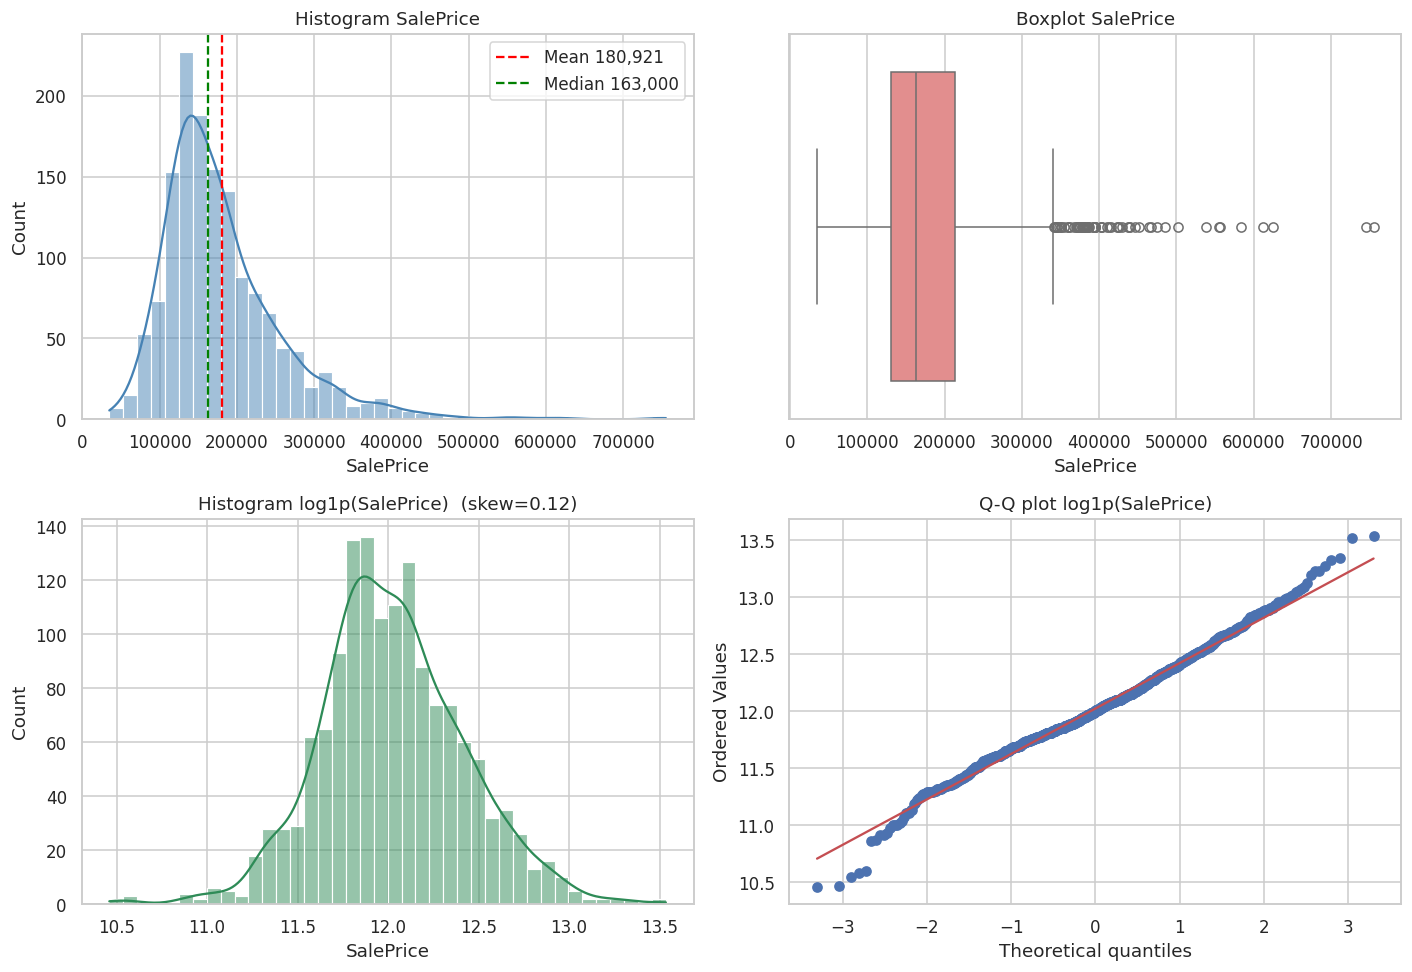


=== Interpretasi otomatis ===
- Rata-rata (180,921) > median (163,000) dan skewness = 1.88 -> distribusi miring ke kanan (right-skewed).
- Terdapat 61 rumah (4.2%) di atas batas atas IQR (340,038) -> segmen rumah mahal.
- Setelah transformasi log1p skewness turun menjadi 0.12, sehingga target lebih mendekati normal. Karena itu seluruh model dilatih pada log1p(SalePrice) dan prediksi dikembalikan ke USD (expm1).


In [16]:
y_raw = train['SalePrice']
desc = y_raw.describe()
skew_raw, kurt_raw = y_raw.skew(), y_raw.kurt()
skew_log = np.log1p(y_raw).skew()
display(desc.to_frame('SalePrice').T)
print(f"Skewness         : {skew_raw:.3f}")
print(f"Kurtosis         : {kurt_raw:.3f}")
print(f"Skewness log1p   : {skew_log:.3f}")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(y_raw, kde=True, bins=40, ax=ax[0, 0], color='steelblue')
ax[0, 0].axvline(y_raw.mean(), color='red', ls='--', label=f'Mean {y_raw.mean():,.0f}')
ax[0, 0].axvline(y_raw.median(), color='green', ls='--', label=f'Median {y_raw.median():,.0f}')
ax[0, 0].legend(); ax[0, 0].set_title('Histogram SalePrice')
sns.boxplot(x=y_raw, ax=ax[0, 1], color='lightcoral'); ax[0, 1].set_title('Boxplot SalePrice')
sns.histplot(np.log1p(y_raw), kde=True, bins=40, ax=ax[1, 0], color='seagreen')
ax[1, 0].set_title(f'Histogram log1p(SalePrice)  (skew={skew_log:.2f})')
stats.probplot(np.log1p(y_raw), dist='norm', plot=ax[1, 1]); ax[1, 1].set_title('Q-Q plot log1p(SalePrice)')
plt.tight_layout(); save_fig('01_saleprice_distribution.png'); plt.show()

q1, q3 = y_raw.quantile([.25, .75]); iqr = q3 - q1
n_up = (y_raw > q3 + 1.5 * iqr).sum()
print("\n=== Interpretasi otomatis ===")
print(f"- Rata-rata ({y_raw.mean():,.0f}) {'>' if y_raw.mean() > y_raw.median() else '<='} median ({y_raw.median():,.0f}) "
      f"dan skewness = {skew_raw:.2f} -> distribusi {'miring ke kanan (right-skewed)' if skew_raw > 0.5 else 'relatif simetris'}.")
print(f"- Terdapat {n_up} rumah ({n_up/len(y_raw)*100:.1f}%) di atas batas atas IQR ({q3 + 1.5*iqr:,.0f}) -> segmen rumah mahal.")
print(f"- Setelah transformasi log1p skewness turun menjadi {skew_log:.2f}, sehingga target lebih mendekati normal. "
      f"Karena itu seluruh model dilatih pada log1p(SalePrice) dan prediksi dikembalikan ke USD (expm1).")

## 7.2 Hubungan kualitas, lingkungan, dan harga

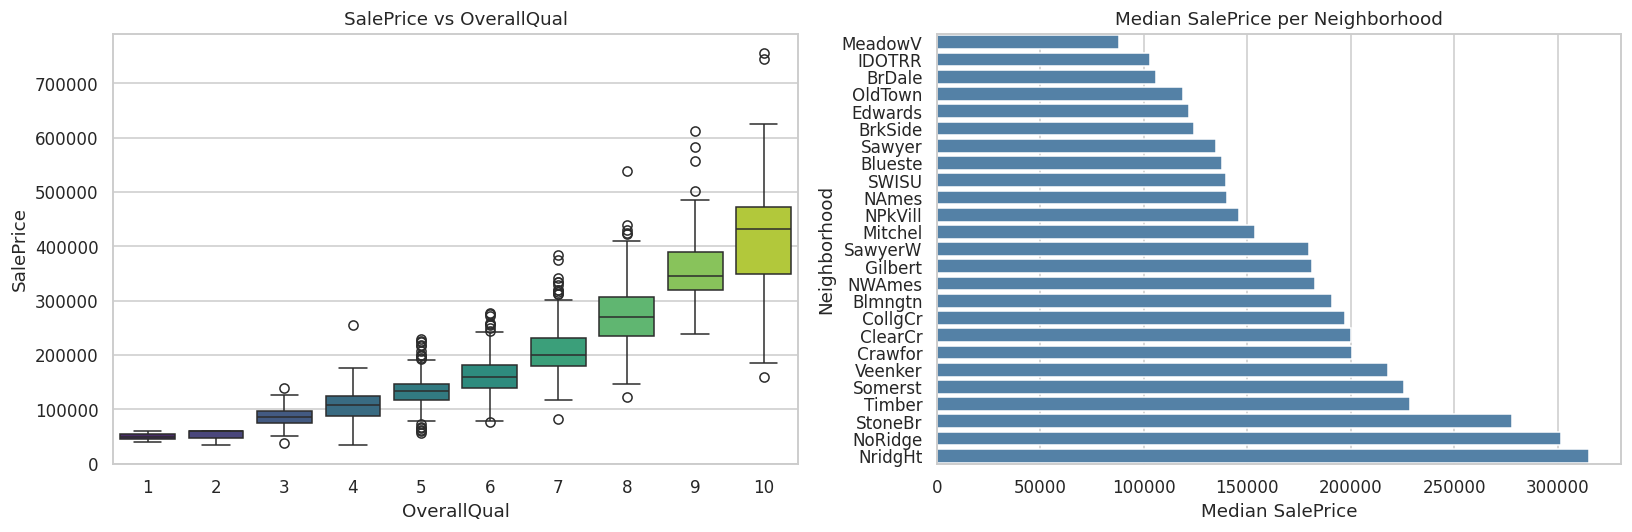

=== Interpretasi otomatis ===
- Median harga naik dari 50,150 (OverallQual=1) menjadi 432,390 (OverallQual=10): kualitas material/finishing sangat terkait harga.
- Median harga tertinggi: NridgHt (315,000); terendah: MeadowV (88,000) -> lokasi (Neighborhood) membedakan harga 3.6x.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=ax[0], palette='viridis')
ax[0].set_title('SalePrice vs OverallQual')
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values()
sns.barplot(x=order.values, y=order.index, ax=ax[1], color='steelblue')
ax[1].set_title('Median SalePrice per Neighborhood'); ax[1].set_xlabel('Median SalePrice')
plt.tight_layout(); save_fig('12_eda_quality_neighborhood.png'); plt.show()

med_q = train.groupby('OverallQual')['SalePrice'].median()
print("=== Interpretasi otomatis ===")
print(f"- Median harga naik dari {med_q.iloc[0]:,.0f} (OverallQual={med_q.index[0]}) "
      f"menjadi {med_q.iloc[-1]:,.0f} (OverallQual={med_q.index[-1]}): kualitas material/finishing sangat terkait harga.")
print(f"- Median harga tertinggi: {order.index[-1]} ({order.iloc[-1]:,.0f}); terendah: {order.index[0]} ({order.iloc[0]:,.0f}) "
      f"-> lokasi (Neighborhood) membedakan harga {order.iloc[-1]/order.iloc[0]:.1f}x.")

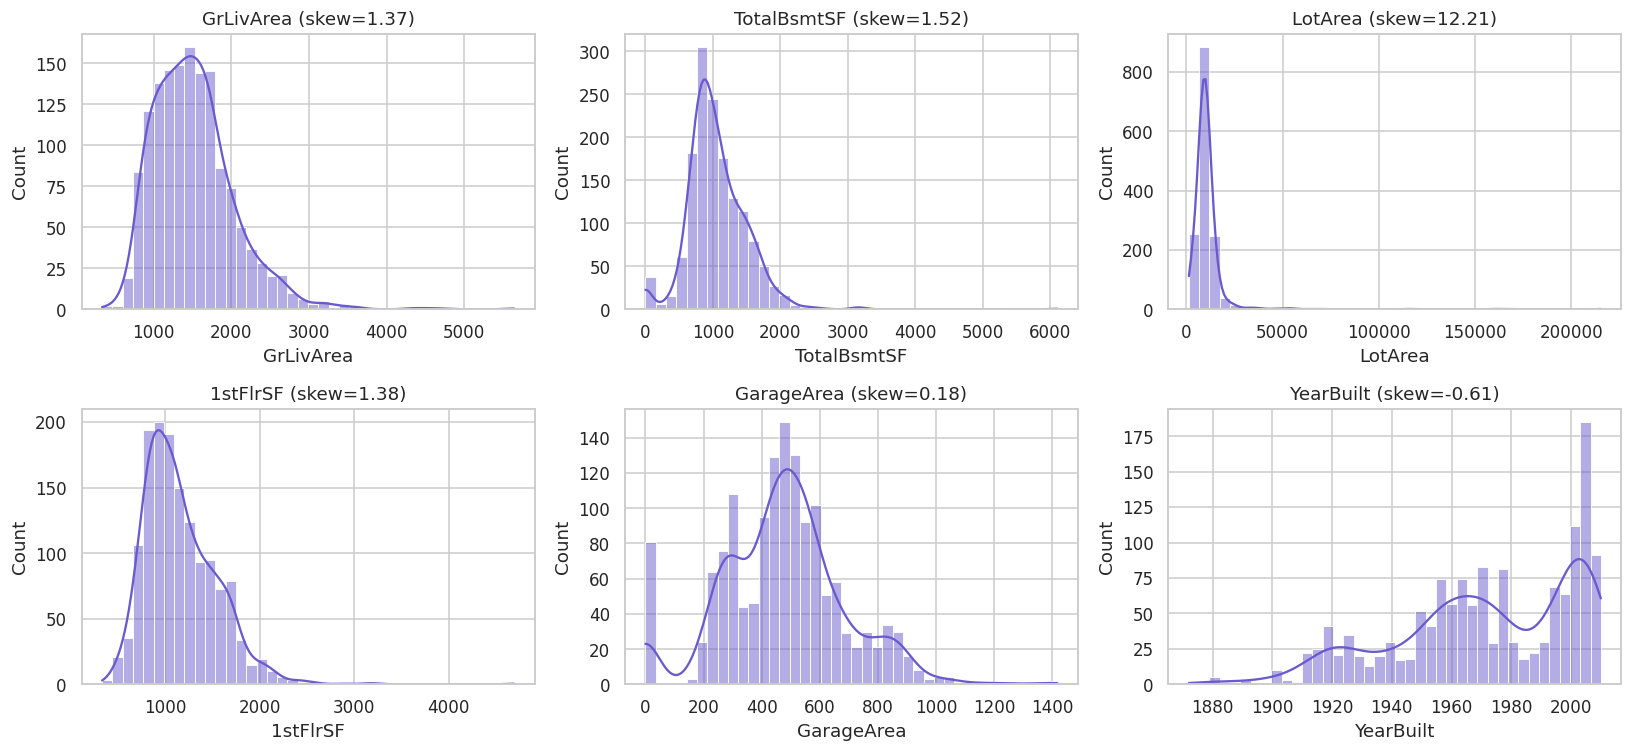

Kardinalitas fitur kategorikal (5 tertinggi):
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
Total kategori jika di-one-hot (kasar): 251 kolom dummy dari 43 fitur kategorikal


In [18]:
# Distribusi beberapa fitur numerik utama
feats = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF', 'GarageArea', 'YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(axes.ravel(), feats):
    sns.histplot(train[c].dropna(), bins=40, kde=True, ax=a, color='slateblue')
    a.set_title(f'{c} (skew={train[c].skew():.2f})')
plt.tight_layout(); plt.show()

card = train[cat_cols_raw].nunique().sort_values(ascending=False)
print("Kardinalitas fitur kategorikal (5 tertinggi):"); print(card.head(5).to_string())
print(f"Total kategori jika di-one-hot (kasar): {card.sum()} kolom dummy dari {len(cat_cols_raw)} fitur kategorikal")

**Interpretasi:** fitur luas (mis. `LotArea`, `GrLivArea`) cenderung miring ke kanan, sehingga model linear berpotensi dipengaruhi nilai ekstrem — alasan kuat untuk mengecek outlier dan memakai regularisasi. Fitur kategorikal dengan kardinalitas tinggi (mis. `Neighborhood`) menghasilkan banyak kolom dummy; `OneHotEncoder(handle_unknown='ignore')` dipakai agar kategori baru tidak menyebabkan error.

# 8. Missing Value Analysis
Tidak semua missing value sama. Pada dataset ini banyak `NaN` **bukan data hilang**, melainkan kode `NA` pada `data_description.txt` yang berarti *fasilitas tidak ada* (mis. tidak ada kolam → `PoolQC` = NA). Mengisinya dengan mean/median akan menyesatkan.

Train: 19 fitur memiliki missing value


,Feature,Missing Count,Missing Percentage
0,PoolQC,1453,99.52
1,MiscFeature,1406,96.30
2,Alley,1369,93.77
3,Fence,1179,80.75
4,MasVnrType,872,59.73
5,FireplaceQu,690,47.26
6,LotFrontage,259,17.74
7,GarageType,81,5.55
8,GarageYrBlt,81,5.55
9,GarageFinish,81,5.55


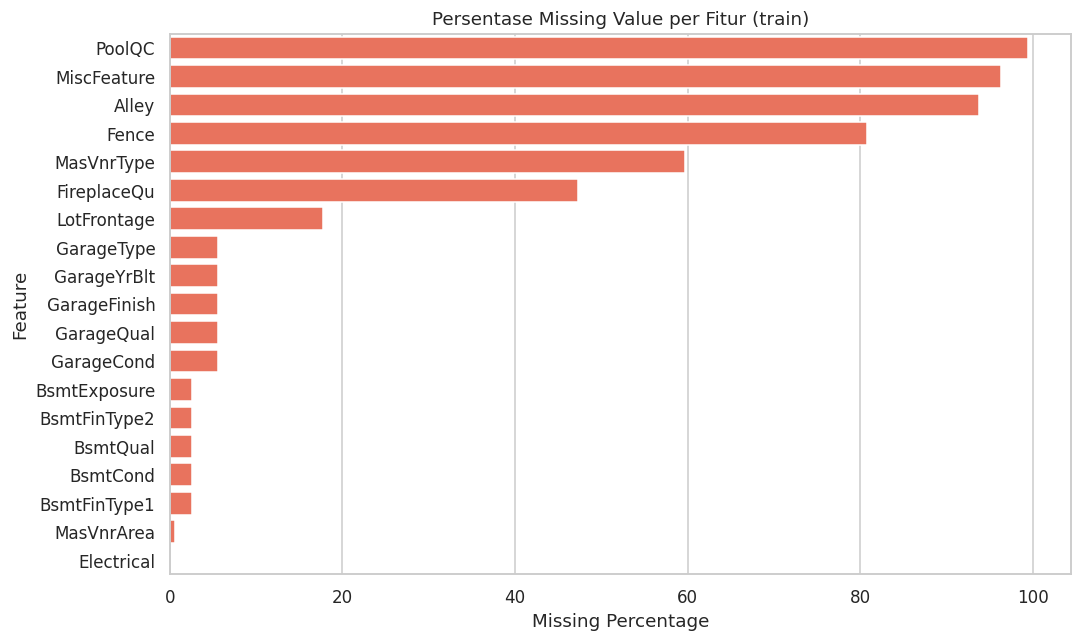


Test: 33 fitur memiliki missing value; 15 di antaranya tidak bermissing di train:


,Feature,Missing Count,Missing Percentage
18,MSZoning,4,0.27
19,Functional,2,0.14
20,BsmtFullBath,2,0.14
21,Utilities,2,0.14
22,BsmtHalfBath,2,0.14
23,Exterior1st,1,0.07
24,Exterior2nd,1,0.07
25,TotalBsmtSF,1,0.07
26,BsmtUnfSF,1,0.07
27,BsmtFinSF2,1,0.07


In [19]:
def missing_table(d):
    mc = d.isna().sum()
    t = pd.DataFrame({'Feature': mc.index, 'Missing Count': mc.values,
                      'Missing Percentage': (mc.values / len(d) * 100).round(2)})
    return t[t['Missing Count'] > 0].sort_values('Missing Count', ascending=False).reset_index(drop=True)

miss_train = missing_table(train.drop(columns='SalePrice'))
print(f"Train: {len(miss_train)} fitur memiliki missing value")
display(miss_train)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=miss_train, y='Feature', x='Missing Percentage', color='tomato', ax=ax)
ax.set_title('Persentase Missing Value per Fitur (train)')
plt.tight_layout(); save_fig('02_missing_values.png'); plt.show()

miss_test = missing_table(test)
only_test = miss_test[~miss_test['Feature'].isin(miss_train['Feature'])]
print(f"\nTest: {len(miss_test)} fitur memiliki missing value; {len(only_test)} di antaranya tidak bermissing di train:")
display(only_test)

In [20]:
# ---- Aturan penanganan missing value STRUKTURAL (NA = fasilitas tidak ada) ----
# kolom -> (kolom ukuran penentu keberadaan fasilitas, nilai yang berarti "tidak ada")
ABSENT_RULES = {
    'PoolQC': ('PoolArea', 0), 'FireplaceQu': ('Fireplaces', 0),
    'GarageType': ('GarageArea', 0), 'GarageFinish': ('GarageArea', 0),
    'GarageQual': ('GarageArea', 0), 'GarageCond': ('GarageArea', 0),
    'BsmtQual': ('TotalBsmtSF', 0), 'BsmtCond': ('TotalBsmtSF', 0),
    'BsmtExposure': ('TotalBsmtSF', 0), 'BsmtFinType1': ('TotalBsmtSF', 0),
    'BsmtFinType2': ('TotalBsmtSF', 0),
}
# Tidak punya kolom ukuran; NA di data_description berarti tidak ada
ALWAYS_NONE = ['Alley', 'Fence', 'MiscFeature', 'MasVnrType']
# Numerik yang NaN hanya jika bangunan/fitur tidak ada -> 0
ZERO_FILL = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']

# ---- Encoding ordinal (urutan kualitas bermakna) ----
QUAL_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
QUAL_COLS = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
ORDINAL_MAPS = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'CentralAir': {'N': 0, 'Y': 1},
}

## 8.1 Verifikasi: apakah missing = "fasilitas tidak ada"?
Dibuktikan dengan membandingkan `NaN` pada kolom kategori dengan kolom ukuran terkait (mis. `PoolQC` kosong ⇔ `PoolArea == 0`).

In [21]:
rows = []
for col, (size_col, absent_val) in ABSENT_RULES.items():
    na = train[col].isna()
    absent = train[size_col] == absent_val
    rows.append({'Feature': col, 'Kolom penentu': f'{size_col}=={absent_val}',
                 'NaN': int(na.sum()), 'Fasilitas tidak ada': int(absent.sum()),
                 'NaN & tidak ada': int((na & absent).sum()),
                 'NaN tapi fasilitas ada (missing sungguhan)': int((na & ~absent).sum())})
for col in ALWAYS_NONE:
    rows.append({'Feature': col, 'Kolom penentu': '(tanpa kolom ukuran)', 'NaN': int(train[col].isna().sum()),
                 'Fasilitas tidak ada': '-', 'NaN & tidak ada': '-', 'NaN tapi fasilitas ada (missing sungguhan)': '-'})
verif = pd.DataFrame(rows)
display(verif)

true_missing = int(verif['NaN tapi fasilitas ada (missing sungguhan)'].replace('-', 0).sum())
print("=== Interpretasi otomatis ===")
print(f"- Pada {len(ABSENT_RULES)} kolom ber-kolom-ukuran, jumlah NaN hampir selalu = jumlah rumah tanpa fasilitas tersebut; "
      f"hanya {true_missing} sel yang NaN padahal fasilitas ada (missing sungguhan -> diimputasi).")
print(f"- Missing 'struktural' (berarti tidak ada) -> diisi 'None' (kategori) / 0 (numerik). Alley, Fence, MiscFeature: NA = tidak ada.")
print(f"- MasVnrType: nilai 'None' di CSV (tidak ada veneer) otomatis dibaca pandas sebagai NaN (pandas >= 2.0), jadi "
      f"dari {train['MasVnrType'].isna().sum()} NaN, hanya {int(train['MasVnrArea'].isna().sum())} yang benar-benar tak diketahui (MasVnrArea juga kosong); sisanya = tidak ada veneer -> diisi 'None'.")

,Feature,Kolom penentu,NaN,Fasilitas tidak ada,NaN & tidak ada,NaN tapi fasilitas ada (missing sungguhan)
0,PoolQC,PoolArea==0,1453,1453,1453,0
1,FireplaceQu,Fireplaces==0,690,690,690,0
2,GarageType,GarageArea==0,81,81,81,0
3,GarageFinish,GarageArea==0,81,81,81,0
4,GarageQual,GarageArea==0,81,81,81,0
5,GarageCond,GarageArea==0,81,81,81,0
6,BsmtQual,TotalBsmtSF==0,37,37,37,0
7,BsmtCond,TotalBsmtSF==0,37,37,37,0
8,BsmtExposure,TotalBsmtSF==0,38,37,37,1
9,BsmtFinType1,TotalBsmtSF==0,37,37,37,0


=== Interpretasi otomatis ===
- Pada 11 kolom ber-kolom-ukuran, jumlah NaN hampir selalu = jumlah rumah tanpa fasilitas tersebut; hanya 2 sel yang NaN padahal fasilitas ada (missing sungguhan -> diimputasi).
- Missing 'struktural' (berarti tidak ada) -> diisi 'None' (kategori) / 0 (numerik). Alley, Fence, MiscFeature: NA = tidak ada.
- MasVnrType: nilai 'None' di CSV (tidak ada veneer) otomatis dibaca pandas sebagai NaN (pandas >= 2.0), jadi dari 872 NaN, hanya 8 yang benar-benar tak diketahui (MasVnrArea juga kosong); sisanya = tidak ada veneer -> diisi 'None'.


## 8.2 Strategi penanganan
| Jenis missing | Contoh | Penanganan | Dilakukan di |
|---|---|---|---|
| **Struktural** (fasilitas tidak ada) | `PoolQC`, `GarageType`, `GarageFinish`, `BsmtQual`, `FireplaceQu`, `Alley`, `Fence`, `MiscFeature` | kategori → `'None'`, numerik (`MasVnrArea`, `Bsmt*`) → `0` | `handle_structural_missing()` (aturan tetap, tanpa belajar dari data → bebas leakage) |
| **Missing sungguhan – numerik** | `LotFrontage`, sebagian kecil kolom lain | **median** | `SimpleImputer(strategy='median')` dalam Pipeline (di-*fit* hanya pada data latih) |
| **Missing sungguhan – kategorikal** | `Electrical`, `MSZoning`, `KitchenQual`, dll. | **modus** | `SimpleImputer(strategy='most_frequent')` dalam Pipeline |
| Kolom dibuang | `GarageYrBlt` | kosong bila tidak ada garasi & sangat berkorelasi dengan `YearBuilt`; diganti flag `HasGarage` | `engineer_features()` |

# 9. Outlier Analysis
Metode: boxplot + aturan **IQR** (1.5×IQR), **z-score**, dan scatterplot terhadap `SalePrice`. Outlier **tidak otomatis dihapus**; hanya titik yang terbukti tidak mewakili pola umum yang dikeluarkan, dan setiap penghapusan dijelaskan.

,Outlier IQR,% data,Max z-score
LotFrontage,88,7.33,10.01
MasVnrArea,96,6.61,8.27
LotArea,69,4.73,20.52
TotalBsmtSF,61,4.18,11.52
SalePrice,61,4.18,7.23
GrLivArea,31,2.12,7.86
GarageArea,21,1.44,4.42
1stFlrSF,20,1.37,9.13


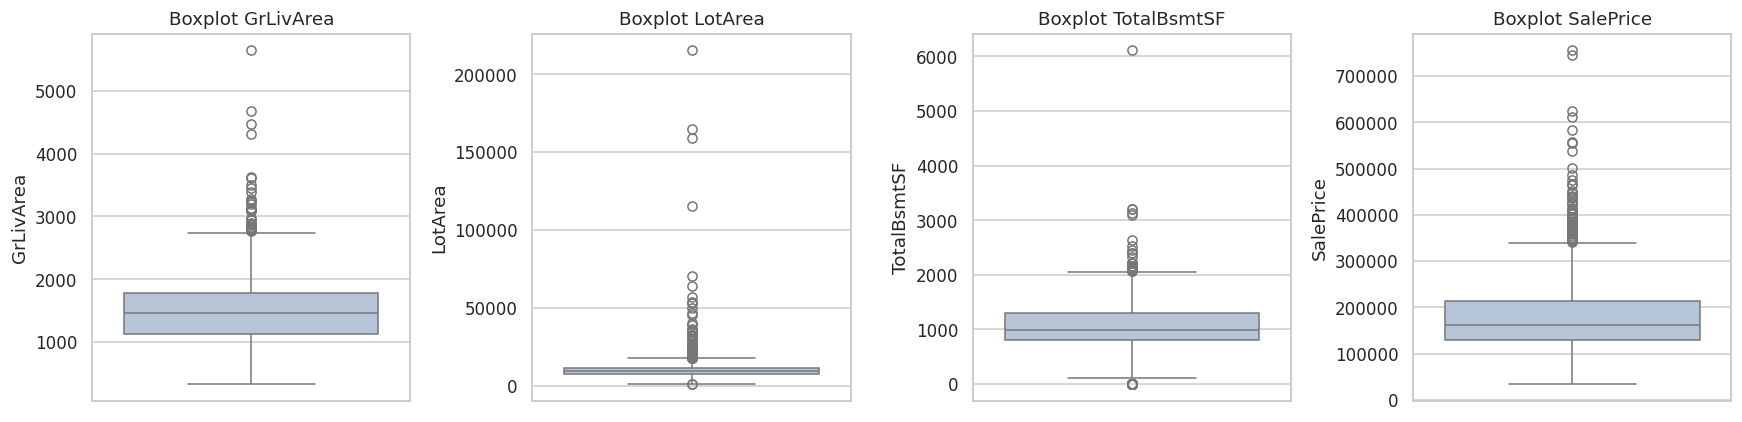

In [22]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return ((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum()

core = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotFrontage', 'MasVnrArea', 'SalePrice']
iqr_tab = pd.DataFrame({'Outlier IQR': [iqr_outliers(train[c].dropna()) for c in core]}, index=core)
iqr_tab['% data'] = (iqr_tab['Outlier IQR'] / train[core].notna().sum() * 100).round(2)
iqr_tab['Max z-score'] = [np.abs(stats.zscore(train[c].dropna())).max().round(2) for c in core]
display(iqr_tab.sort_values('% data', ascending=False))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(ax, ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice']):
    sns.boxplot(y=train[c], ax=a, color='lightsteelblue'); a.set_title(f'Boxplot {c}')
plt.tight_layout(); save_fig('03a_boxplot_outlier.png'); plt.show()

## 9.1 `GrLivArea` vs `SalePrice` (analisis wajib)

Kandidat outlier (GrLivArea > 4000):


,Id,GrLivArea,SalePrice,OverallQual,SaleCondition,Neighborhood,YearBuilt
523,524,4676,184750,10,Partial,Edwards,2007
691,692,4316,755000,10,Normal,NoRidge,1994
1182,1183,4476,745000,10,Abnorml,NoRidge,1996
1298,1299,5642,160000,10,Partial,Edwards,2008


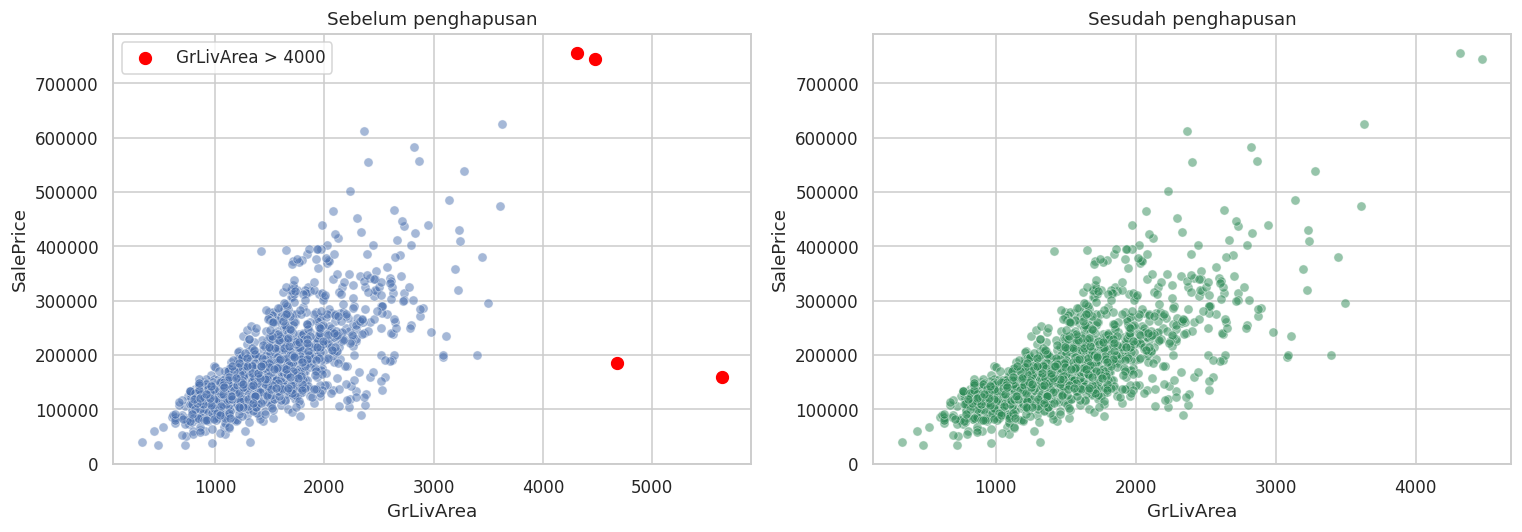


=== Keputusan & interpretasi otomatis ===
- Dihapus: Id [524, 1299] (GrLivArea > 4000 dan SalePrice < 300.000) -> 2 baris; sisa data = 1458.
- Alasan: rumah sangat luas dengan harga jauh di bawah tren (lihat tabel: SaleCondition & harga) menyimpang dari hubungan luas-harga dan menarik garis regresi.
- Dampak: korelasi GrLivArea-SalePrice 0.709 -> 0.735; slope regresi 107.1 -> 115.0 USD/sqft.
- Dipertahankan: Id [692, 1183] (luas > 4000 dengan harga tinggi) karena mengikuti pola luas-harga (rumah mewah yang valid).
- Outlier IQR lain (mis. LotArea, SalePrice tinggi) DIPERTAHANKAN: merupakan variasi nyata (lahan besar / rumah mahal); dampaknya diredam oleh log-transform target, scaling, regularisasi, dan model berbasis pohon.


In [23]:
cand = (train['GrLivArea'] > 4000)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', alpha=.5, ax=ax[0])
sns.scatterplot(data=train[cand], x='GrLivArea', y='SalePrice', color='red', s=90, ax=ax[0], label='GrLivArea > 4000')
ax[0].set_title('Sebelum penghapusan'); ax[0].legend()

print("Kandidat outlier (GrLivArea > 4000):")
display(train.loc[cand, ['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'SaleCondition', 'Neighborhood', 'YearBuilt']])

# Keputusan: hapus hanya yang luasnya ekstrem TETAPI harganya jauh di bawah pola
outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
removed_ids = train.loc[outlier_mask, 'Id'].tolist()
train_clean = train.loc[~outlier_mask].reset_index(drop=True)

r_before = train[['GrLivArea', 'SalePrice']].corr().iloc[0, 1]
r_after = train_clean[['GrLivArea', 'SalePrice']].corr().iloc[0, 1]
sl_before = stats.linregress(train['GrLivArea'], train['SalePrice']).slope
sl_after = stats.linregress(train_clean['GrLivArea'], train_clean['SalePrice']).slope

sns.scatterplot(data=train_clean, x='GrLivArea', y='SalePrice', alpha=.5, ax=ax[1], color='seagreen')
ax[1].set_title('Sesudah penghapusan'); plt.tight_layout(); save_fig('03_outlier_grlivarea.png'); plt.show()

print("\n=== Keputusan & interpretasi otomatis ===")
print(f"- Dihapus: Id {removed_ids} (GrLivArea > 4000 dan SalePrice < 300.000) -> {len(removed_ids)} baris; sisa data = {len(train_clean)}.")
print(f"- Alasan: rumah sangat luas dengan harga jauh di bawah tren (lihat tabel: SaleCondition & harga) "
      f"menyimpang dari hubungan luas-harga dan menarik garis regresi.")
print(f"- Dampak: korelasi GrLivArea-SalePrice {r_before:.3f} -> {r_after:.3f}; slope regresi {sl_before:,.1f} -> {sl_after:,.1f} USD/sqft.")
kept = train.loc[cand & ~outlier_mask, 'Id'].tolist()
print(f"- Dipertahankan: Id {kept} (luas > 4000 dengan harga tinggi) karena mengikuti pola luas-harga (rumah mewah yang valid).")
print("- Outlier IQR lain (mis. LotArea, SalePrice tinggi) DIPERTAHANKAN: merupakan variasi nyata (lahan besar / rumah mahal); "
      "dampaknya diredam oleh log-transform target, scaling, regularisasi, dan model berbasis pohon.")

In [24]:
# Uji dampak penghapusan: latih Ridge dengan vs tanpa 2 outlier, dievaluasi pada hold-out yang sama (dijalankan di bagian 15.2)
print("Dampak penghapusan terhadap error model akan diuji empiris di bagian 15.2.")

Dampak penghapusan terhadap error model akan diuji empiris di bagian 15.2.


# 10. Feature Analysis
Korelasi dihitung pada `train_clean` (setelah outlier dikeluarkan) untuk fitur numerik asli.

10 fitur dengan korelasi positif tertinggi terhadap SalePrice:


,Pearson r
OverallQual,0.796
GrLivArea,0.735
TotalBsmtSF,0.651
GarageCars,0.641
1stFlrSF,0.632
GarageArea,0.629
FullBath,0.562
TotRmsAbvGrd,0.538
YearBuilt,0.524
YearRemodAdd,0.508


5 fitur dengan korelasi negatif terkuat:


,Pearson r
YrSold,-0.029
OverallCond,-0.078
MSSubClass,-0.084
EnclosedPorch,-0.129
KitchenAbvGr,-0.136


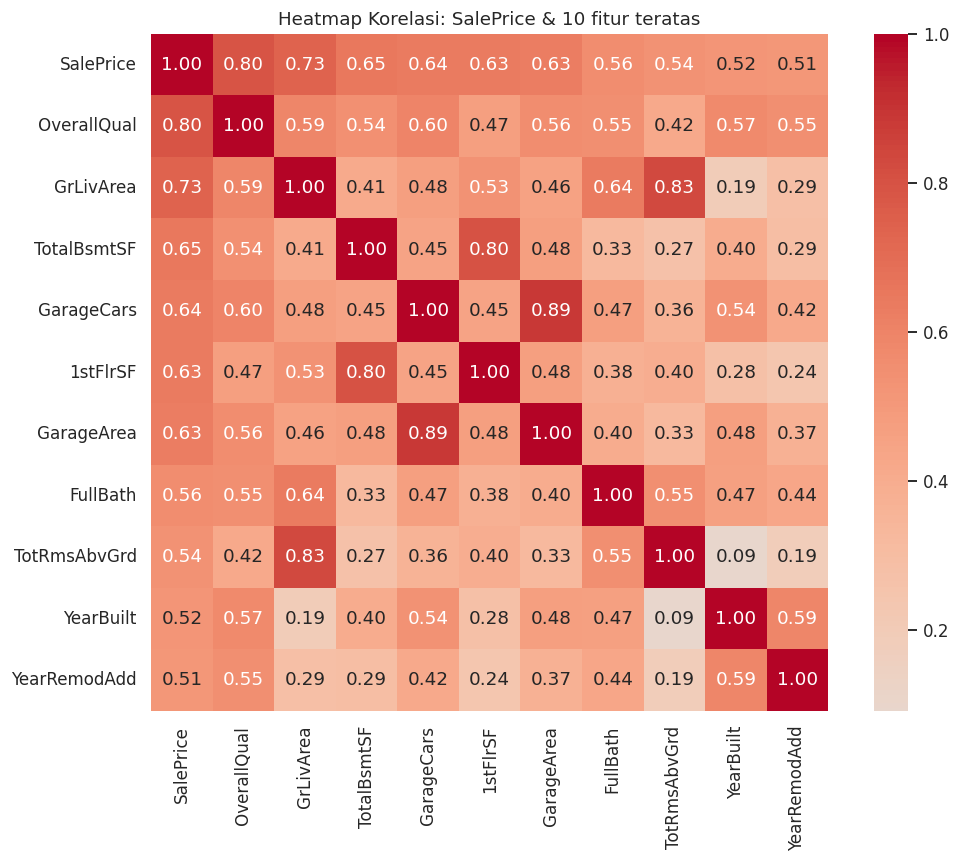

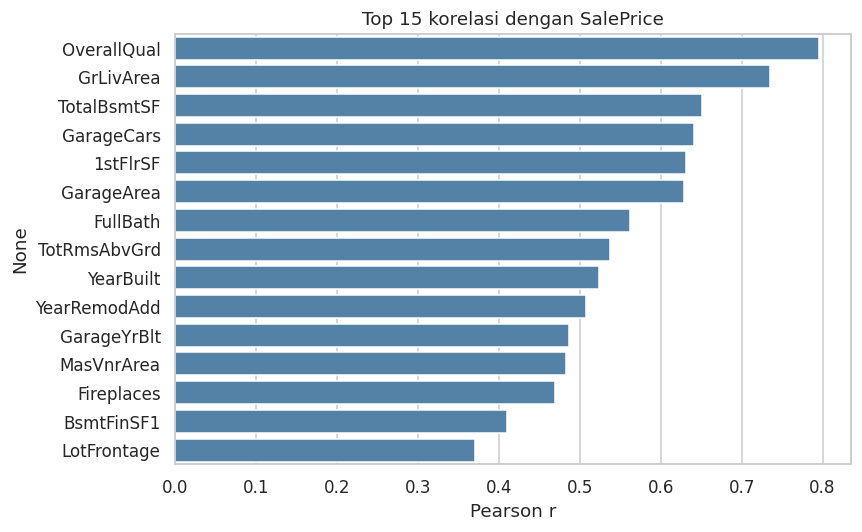

In [25]:
num_df = train_clean.select_dtypes(include='number').drop(columns='Id')
corr = num_df.corr()
corr_target = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)
top_corr = corr_target.head(10)

print("10 fitur dengan korelasi positif tertinggi terhadap SalePrice:")
display(top_corr.round(3).to_frame('Pearson r'))
print("5 fitur dengan korelasi negatif terkuat:")
display(corr_target.tail(5).round(3).to_frame('Pearson r'))

top15 = corr['SalePrice'].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(corr.loc[top15, top15], annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Heatmap Korelasi: SalePrice & 10 fitur teratas'); plt.tight_layout()
save_fig('04_corr_heatmap.png'); plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=corr_target.head(15).values, y=corr_target.head(15).index, color='steelblue')
plt.title('Top 15 korelasi dengan SalePrice'); plt.xlabel('Pearson r'); plt.tight_layout()
save_fig('05_top_corr.png'); plt.show()

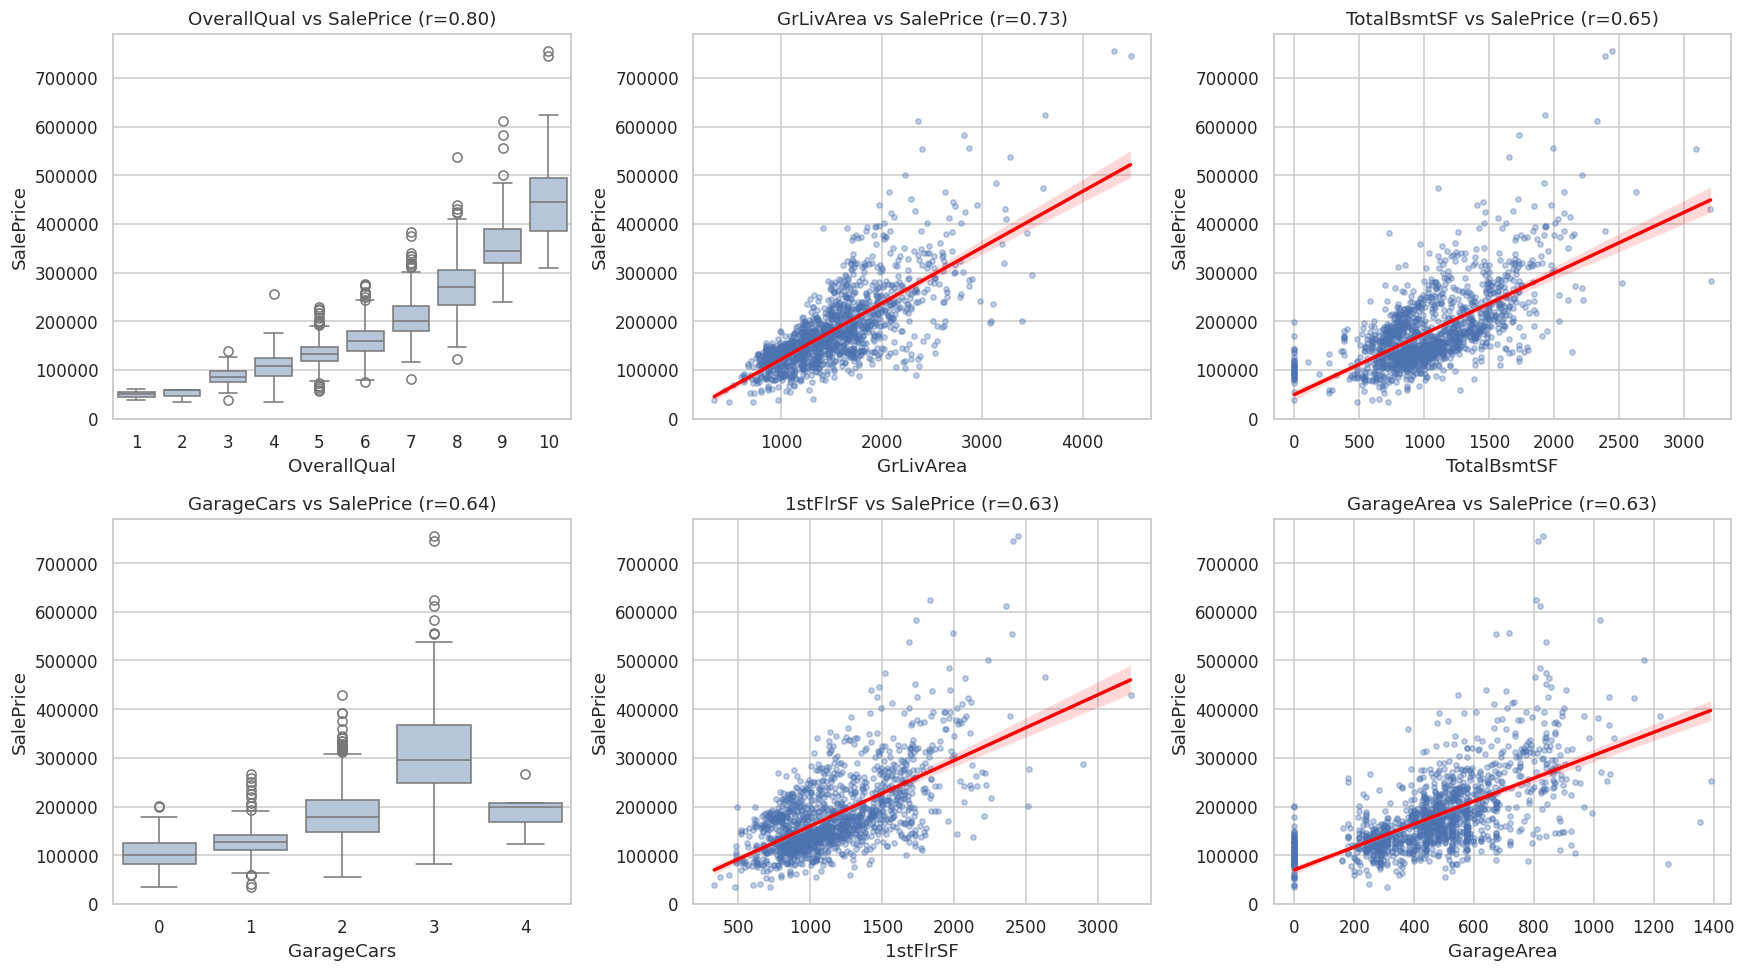

In [26]:
# Scatterplot fitur penting
sc_feats = list(top_corr.index[:6])
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for a, c in zip(axes.ravel(), sc_feats):
    if train_clean[c].nunique() < 15:
        sns.boxplot(data=train_clean, x=c, y='SalePrice', ax=a, color='lightsteelblue')
    else:
        sns.regplot(data=train_clean, x=c, y='SalePrice', ax=a, scatter_kws={'alpha': .35, 's': 12},
                    line_kws={'color': 'red'})
    a.set_title(f'{c} vs SalePrice (r={corr_target[c]:.2f})')
plt.tight_layout(); save_fig('06_scatter_top_features.png'); plt.show()

In [27]:
# Fitur kategorikal: correlation ratio (eta^2) = proporsi varians SalePrice yang dijelaskan kategori
def eta_squared(cat, y):
    g = y.groupby(cat.fillna('NA'))
    ss_between = (g.count() * (g.mean() - y.mean()) ** 2).sum()
    return ss_between / ((y - y.mean()) ** 2).sum()

cat_only = [c for c in train_clean.select_dtypes(exclude='number').columns]
eta = pd.Series({c: eta_squared(train_clean[c], train_clean['SalePrice']) for c in cat_only}).sort_values(ascending=False)
print("10 fitur kategorikal paling menjelaskan variasi SalePrice (eta^2):")
display(eta.head(10).round(3).to_frame('eta^2'))

# Multikolinearitas antar fitur
c_abs = corr.drop(index='SalePrice', columns='SalePrice').abs()
pairs = (c_abs.where(np.triu(np.ones(c_abs.shape), k=1).astype(bool)).stack()
         .sort_values(ascending=False))
print("\nPasangan fitur numerik yang sangat berkorelasi (|r| >= 0.8):")
display(pairs[pairs >= 0.8].round(3).to_frame('|r|'))

print("=== Interpretasi otomatis ===")
print(f"- Fitur numerik terkuat: {top_corr.index[0]} (r={top_corr.iloc[0]:.2f}), {top_corr.index[1]} (r={top_corr.iloc[1]:.2f}), "
      f"{top_corr.index[2]} (r={top_corr.iloc[2]:.2f}). Semua 10 teratas berkorelasi positif (r antara {top_corr.min():.2f} dan {top_corr.max():.2f}).")
print(f"- Fitur kategorikal terkuat: {eta.index[0]} (eta^2={eta.iloc[0]:.2f}), {eta.index[1]} (eta^2={eta.iloc[1]:.2f}).")
print(f"- Ada {int((pairs>=0.8).sum())} pasangan fitur dengan |r| >= 0.8 -> multikolinearitas; Linear Regression biasa berisiko tidak stabil, "
      f"sehingga Ridge/Lasso (regularisasi) layak dibandingkan.")
print("- Korelasi Pearson hanya mengukur hubungan LINEAR; hubungan non-linear/interaksi ditangkap lebih baik oleh model pohon.")

10 fitur kategorikal paling menjelaskan variasi SalePrice (eta^2):


,eta^2
Neighborhood,0.546
ExterQual,0.486
BsmtQual,0.470
KitchenQual,0.462
GarageFinish,0.307
FireplaceQu,0.295
Foundation,0.257
GarageType,0.250
BsmtFinType1,0.212
HeatingQC,0.196



Pasangan fitur numerik yang sangat berkorelasi (|r| >= 0.8):


,,|r|
GarageCars,GarageArea,0.887
GrLivArea,TotRmsAbvGrd,0.829
YearBuilt,GarageYrBlt,0.825
TotalBsmtSF,1stFlrSF,0.804


=== Interpretasi otomatis ===
- Fitur numerik terkuat: OverallQual (r=0.80), GrLivArea (r=0.73), TotalBsmtSF (r=0.65). Semua 10 teratas berkorelasi positif (r antara 0.51 dan 0.80).
- Fitur kategorikal terkuat: Neighborhood (eta^2=0.55), ExterQual (eta^2=0.49).
- Ada 4 pasangan fitur dengan |r| >= 0.8 -> multikolinearitas; Linear Regression biasa berisiko tidak stabil, sehingga Ridge/Lasso (regularisasi) layak dibandingkan.
- Korelasi Pearson hanya mengukur hubungan LINEAR; hubungan non-linear/interaksi ditangkap lebih baik oleh model pohon.


# 11. Feature Engineering
Fitur baru dibuat dari kolom yang **benar-benar ada** pada dataset. Semua transformasi bersifat *per-baris* (tanpa statistik dari seluruh data), sehingga aman dari data leakage.

| Fitur baru | Rumus | Alasan |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | total luas bangunan; pembeli menilai luas total, bukan per lantai |
| `TotalBathrooms` | `FullBath + 0.5·HalfBath + BsmtFullBath + 0.5·BsmtHalfBath` | jumlah kamar mandi efektif (half bath dihitung 0.5) |
| `TotalPorchSF` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch` | total area porch yang tersebar di 4 kolom |
| `HouseAge` | `YrSold − YearBuilt` (min 0) | umur bangunan saat dijual lebih bermakna daripada tahun absolut |
| `RemodAge` | `YrSold − YearRemodAdd` (min 0) | lama sejak renovasi terakhir |
| `IsRemodeled` | `YearRemodAdd ≠ YearBuilt` | apakah pernah direnovasi |
| `HasPool/Garage/Bsmt/2ndFloor/Fireplace` | indikator `>0` | memisahkan efek "ada vs tidak ada" dari efek ukuran |

Selain itu: **encoding ordinal** untuk kolom kualitas (`Po<Fa<TA<Gd<Ex`, dll.) karena urutannya bermakna, `MSSubClass` & `MoSold` dijadikan kategori, dan `Id`/`GarageYrBlt` dibuang.

In [28]:
# ---- Aturan penanganan missing value STRUKTURAL (NA = fasilitas tidak ada) ----
# kolom -> (kolom ukuran penentu keberadaan fasilitas, nilai yang berarti "tidak ada")
ABSENT_RULES = {
    'PoolQC': ('PoolArea', 0), 'FireplaceQu': ('Fireplaces', 0),
    'GarageType': ('GarageArea', 0), 'GarageFinish': ('GarageArea', 0),
    'GarageQual': ('GarageArea', 0), 'GarageCond': ('GarageArea', 0),
    'BsmtQual': ('TotalBsmtSF', 0), 'BsmtCond': ('TotalBsmtSF', 0),
    'BsmtExposure': ('TotalBsmtSF', 0), 'BsmtFinType1': ('TotalBsmtSF', 0),
    'BsmtFinType2': ('TotalBsmtSF', 0),
}
# Tidak punya kolom ukuran; NA di data_description berarti tidak ada
ALWAYS_NONE = ['Alley', 'Fence', 'MiscFeature', 'MasVnrType']
# Numerik yang NaN hanya jika bangunan/fitur tidak ada -> 0
ZERO_FILL = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']

# ---- Encoding ordinal (urutan kualitas bermakna) ----
QUAL_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
QUAL_COLS = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
ORDINAL_MAPS = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'CentralAir': {'N': 0, 'Y': 1},
}

def handle_structural_missing(df):
    """Isi missing value yang berarti 'fasilitas tidak ada'. Aturan tetap (bukan statistik
    yang dipelajari dari data) sehingga aman dilakukan sebelum split."""
    d = df.copy()
    for c in ZERO_FILL:
        if c in d.columns:
            d[c] = d[c].fillna(0)
    for col, (size_col, absent_val) in ABSENT_RULES.items():
        if col in d.columns:
            absent = d[size_col] == absent_val          # NaN pada size_col -> False (tidak diisi)
            d.loc[absent & d[col].isna(), col] = 'None'
    for col in ALWAYS_NONE:
        if col in d.columns:
            d[col] = d[col].fillna('None')
    return d

def engineer_features(df, add_new=True):
    """Pembersihan + encoding ordinal + (opsional) fitur baru. Hanya operasi per-baris,
    tanpa statistik dari data sehingga tidak menimbulkan data leakage."""
    d = handle_structural_missing(df)
    for c in QUAL_COLS:
        d[c] = d[c].map(QUAL_MAP)
    for c, m in ORDINAL_MAPS.items():
        d[c] = d[c].map(m)
    # variabel yang secara makna kategorikal
    d['MSSubClass'] = d['MSSubClass'].astype(str)
    d['MoSold'] = d['MoSold'].astype(str)
    if add_new:
        d['TotalSF'] = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
        d['TotalBathrooms'] = (d['FullBath'] + 0.5 * d['HalfBath']
                               + d['BsmtFullBath'] + 0.5 * d['BsmtHalfBath'])
        d['TotalPorchSF'] = (d['OpenPorchSF'] + d['EnclosedPorch']
                             + d['3SsnPorch'] + d['ScreenPorch'])
        d['HouseAge'] = (d['YrSold'] - d['YearBuilt']).clip(lower=0)
        d['RemodAge'] = (d['YrSold'] - d['YearRemodAdd']).clip(lower=0)
        d['IsRemodeled'] = (d['YearRemodAdd'] != d['YearBuilt']).astype(int)
        d['HasPool'] = (d['PoolArea'] > 0).astype(int)
        d['HasGarage'] = (d['GarageArea'].fillna(0) > 0).astype(int)
        d['HasBsmt'] = (d['TotalBsmtSF'] > 0).astype(int)
        d['Has2ndFloor'] = (d['2ndFlrSF'] > 0).astype(int)
        d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    # Id bukan fitur; GarageYrBlt kosong jika tidak ada garasi & sangat berkolinearitas dengan YearBuilt
    return d.drop(columns=[c for c in ['Id', 'GarageYrBlt'] if c in d.columns])

NEW_FEATURES = ['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge',
                'IsRemodeled', 'HasPool', 'HasGarage', 'HasBsmt', 'Has2ndFloor', 'HasFireplace']

Bentuk X_all            : (1458, 89)
Bentuk X_kaggle_test    : (1459, 89)
Fitur baru              : ['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'IsRemodeled', 'HasPool', 'HasGarage', 'HasBsmt', 'Has2ndFloor', 'HasFireplace']


,min,mean,max
TotalSF,334.0,2557.150206,6872.0
TotalBathrooms,1.0,2.207476,6.0
TotalPorchSF,0.0,86.725652,1027.0
HouseAge,0.0,36.598080,136.0
RemodAge,0.0,22.982167,60.0
IsRemodeled,0.0,0.476680,1.0
HasPool,0.0,0.004115,1.0
HasGarage,0.0,0.944444,1.0
HasBsmt,0.0,0.974623,1.0
Has2ndFloor,0.0,0.431413,1.0


TotalSF   r=+0.833 | komponen: TotalBsmtSF r=+0.651, 1stFlrSF r=+0.632, 2ndFlrSF r=+0.321
HouseAge  r=-0.524 | komponen: YearBuilt r=+0.524
RemodAge  r=-0.510 | komponen: YearRemodAdd r=+0.508
TotalBathrooms r=+0.636
TotalPorchSF   r=+0.197


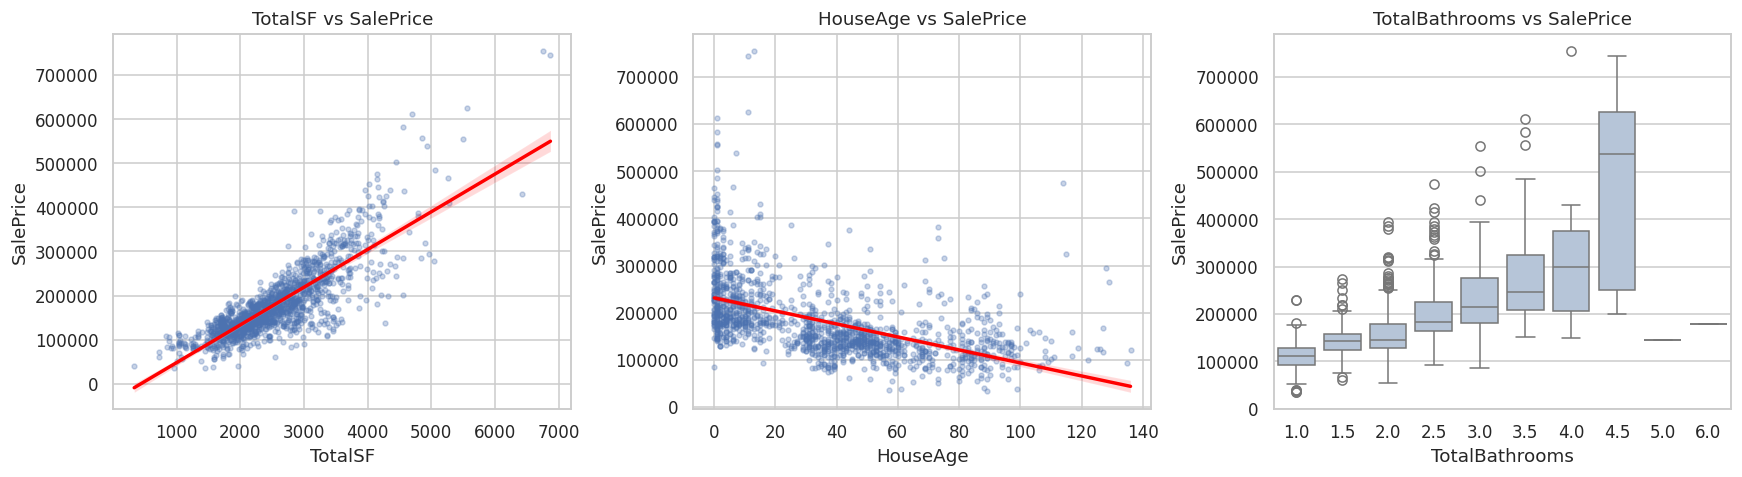


Catatan kualitas data: 1 baris memiliki YrSold < YearBuilt (dijual sebelum selesai dibangun) -> HouseAge di-clip ke 0.
=== Interpretasi otomatis ===
- TotalSF (r=0.833) lebih kuat dibanding komponen terbaiknya (TotalBsmtSF, r=0.651).
- HouseAge berkorelasi NEGATIF dengan harga (r=-0.524): rumah lebih baru cenderung lebih mahal.
- Kontribusi seluruh fitur baru terhadap error model diuji dengan ablation di bagian 15.2.


In [29]:
# Terapkan pada data latih (sudah tanpa outlier) dan test.csv
full = engineer_features(train_clean, add_new=True)
y_all = full.pop('SalePrice')
X_all = full
X_kaggle_test = engineer_features(test, add_new=True)

print("Bentuk X_all            :", X_all.shape)
print("Bentuk X_kaggle_test    :", X_kaggle_test.shape)
print("Fitur baru              :", NEW_FEATURES)
display(X_all[NEW_FEATURES].describe().T[['min', 'mean', 'max']])

# Korelasi fitur baru vs komponennya
chk = X_all[NEW_FEATURES].join(train_clean[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'YearBuilt', 'YearRemodAdd']]).assign(SalePrice=y_all)
cmp_rows = [('TotalSF', ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']), ('HouseAge', ['YearBuilt']), ('RemodAge', ['YearRemodAdd'])]
for new, comps in cmp_rows:
    print(f"{new:<9} r={chk[new].corr(chk['SalePrice']):+.3f} | komponen: " +
          ", ".join(f"{c} r={chk[c].corr(chk['SalePrice']):+.3f}" for c in comps))
for new in ['TotalBathrooms', 'TotalPorchSF']:
    print(f"{new:<14} r={chk[new].corr(chk['SalePrice']):+.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.regplot(x=X_all['TotalSF'], y=y_all, ax=ax[0], scatter_kws={'alpha': .3, 's': 10}, line_kws={'color': 'red'})
ax[0].set_title('TotalSF vs SalePrice')
sns.regplot(x=X_all['HouseAge'], y=y_all, ax=ax[1], scatter_kws={'alpha': .3, 's': 10}, line_kws={'color': 'red'})
ax[1].set_title('HouseAge vs SalePrice')
sns.boxplot(x=X_all['TotalBathrooms'], y=y_all, ax=ax[2], color='lightsteelblue'); ax[2].set_title('TotalBathrooms vs SalePrice')
plt.tight_layout(); save_fig('07_feature_engineering.png'); plt.show()

neg_age = int((test['YrSold'] < test['YearBuilt']).sum() + (train['YrSold'] < train['YearBuilt']).sum())
print(f"\nCatatan kualitas data: {neg_age} baris memiliki YrSold < YearBuilt (dijual sebelum selesai dibangun) -> HouseAge di-clip ke 0.")
print("=== Interpretasi otomatis ===")
best_comp = max(['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], key=lambda c: chk[c].corr(chk['SalePrice']))
print(f"- TotalSF (r={chk['TotalSF'].corr(chk['SalePrice']):.3f}) {'lebih kuat' if chk['TotalSF'].corr(chk['SalePrice']) > chk[best_comp].corr(chk['SalePrice']) else 'tidak lebih kuat'} "
      f"dibanding komponen terbaiknya ({best_comp}, r={chk[best_comp].corr(chk['SalePrice']):.3f}).")
print(f"- HouseAge berkorelasi NEGATIF dengan harga (r={chk['HouseAge'].corr(chk['SalePrice']):.3f}): rumah lebih baru cenderung lebih mahal.")
print("- Kontribusi seluruh fitur baru terhadap error model diuji dengan ablation di bagian 15.2.")

# 12. Preprocessing
Struktur (semua di dalam `Pipeline` agar tidak ada data leakage — statistik imputer/scaler/encoder hanya dipelajari dari **data latih** saat `.fit()`):

```
TransformedTargetRegressor (log1p target -> expm1 prediksi)
 └── Pipeline
      ├── ColumnTransformer
      │    ├── num : SimpleImputer(median) -> StandardScaler (hanya model linear)
      │    └── cat : SimpleImputer(most_frequent) -> OneHotEncoder(handle_unknown='ignore')
      └── Regressor
```

In [30]:
def build_preprocessor(X, scale=True):
    """ColumnTransformer: numerik -> median imputer (+ StandardScaler),
    kategorikal -> modus imputer + OneHotEncoder(handle_unknown='ignore').
    Semua statistik dipelajari hanya saat .fit() pada data latih."""
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        num_steps.append(('scaler', StandardScaler()))
    cat_steps = [('imputer', SimpleImputer(strategy='most_frequent')),
                 ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]
    return ColumnTransformer([('num', Pipeline(num_steps), num_cols),
                              ('cat', Pipeline(cat_steps), cat_cols)], remainder='drop')

prep_demo = build_preprocessor(X_all, scale=True)
num_features = X_all.select_dtypes(include='number').columns.tolist()
cat_features = [c for c in X_all.columns if c not in num_features]
print(f"Fitur numerik     : {len(num_features)}")
print(f"Fitur kategorikal : {len(cat_features)}")
print(f"Missing value tersisa SETELAH penanganan struktural (akan diimputasi di Pipeline): "
      f"{int(X_all.isna().sum().sum())} sel pada {int((X_all.isna().sum()>0).sum())} kolom")
display(X_all.isna().sum()[lambda s: s > 0].sort_values(ascending=False).to_frame('Missing (sungguhan)'))
prep_demo

Fitur numerik     : 59
Fitur kategorikal : 30
Missing value tersisa SETELAH penanganan struktural (akan diimputasi di Pipeline): 262 sel pada 4 kolom


,Missing (sungguhan)
LotFrontage,259
BsmtExposure,1
BsmtFinType2,1
Electrical,1


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LotFrontage', 'LotArea', 'OverallQual',
                                  'OverallCond', 'YearBuilt', 'YearRemodAdd',
                                  'MasVnrArea', 'ExterQual', 'ExterCond',
                                  'BsmtQual', 'BsmtCond', 'BsmtExposure',
                                  'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
                                  'BsmtFinSF2', 'BsmtUnfSF...
                                 ['MSSubClass', 'MSZoning', 'Street', 'Alley',
                                  'LotShape', 'LandContour', 'Utilities',
                                  'LotConfig', 'LandSlope', 'Neighborhood',
                                  'Condition1', 'Condition2', 'BldgType',
                                  'HouseStyle', 'RoofStyle', 'RoofMatl',
                                  'Exterior1st', 'Exterior2nd', 'MasVnrType',
                                  'Foundation', 'Heating', 'Electrical',
                                  'Functional', 'GarageType', 'PavedDrive',
                                  'Fence', 'MiscFeature', 'MoSold', 'SaleType',
                                  'SaleCondition'])])

**Apakah scaling diperlukan?** Dijawab secara empiris di bagian 15.2 (Ridge dengan vs tanpa `StandardScaler`). Model pohon (Random Forest, Gradient Boosting, XGBoost) tidak sensitif terhadap skala sehingga dipasangkan dengan preprocessor **tanpa** scaler.

# 13. Train-Test Split
`train_test_split(test_size=0.2, random_state=42)`. Karena seluruh imputer/scaler/encoder berada di dalam Pipeline, mereka hanya di-*fit* pada `X_train`.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=RANDOM_STATE)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: mean={y_train.mean():,.0f}, median={y_train.median():,.0f} | y_test: mean={y_test.mean():,.0f}, median={y_test.median():,.0f}")

# Demonstrasi: preprocessor di-fit pada TRAIN saja, lalu hanya transform pada TEST
demo = build_preprocessor(X_train, scale=True).fit(X_train)
Xt_train, Xt_test = demo.transform(X_train), demo.transform(X_test)
print(f"\nSetelah preprocessing: train {Xt_train.shape}, test {Xt_test.shape}  (jumlah kolom sama)")
print(f"NaN tersisa: train={np.isnan(Xt_train).sum()}, test={np.isnan(Xt_test).sum()}")

# Kategori yang muncul di test tetapi tidak pernah dilihat saat fit
unseen = {c: sorted(set(X_test[c].dropna()) - set(X_train[c].dropna())) for c in cat_features}
unseen = {c: v for c, v in unseen.items() if v}
unseen_kaggle = {c: sorted(set(X_kaggle_test[c].dropna()) - set(X_all[c].dropna())) for c in cat_features}
unseen_kaggle = {c: v for c, v in unseen_kaggle.items() if v}
print(f"Kategori tak dikenal pada hold-out: {unseen if unseen else 'tidak ada'}")
print(f"Kategori tak dikenal pada test.csv Kaggle: {unseen_kaggle if unseen_kaggle else 'tidak ada'}")
print("-> handle_unknown='ignore' membuat kategori seperti ini menjadi vektor nol (tidak error).")

X_train: (1166, 89) | X_test: (292, 89)
y_train: mean=180,824, median=162,250 | y_test: mean=181,369, median=167,050

Setelah preprocessing: train (1166, 273), test (292, 273)  (jumlah kolom sama)
NaN tersisa: train=0, test=0
Kategori tak dikenal pada hold-out: {'RoofMatl': ['Membran'], 'Electrical': ['Mix'], 'Functional': ['Sev']}
Kategori tak dikenal pada test.csv Kaggle: {'MSSubClass': ['150']}
-> handle_unknown='ignore' membuat kategori seperti ini menjadi vektor nol (tidak error).


# 14. Model Building
Model yang dibandingkan (semua dilatih pada `log1p(SalePrice)`):

1. **Linear Regression** – baseline.
2. **Ridge** (L2) – menangani multikolinearitas; `alpha` dipilih dengan `GridSearchCV` 5-fold pada data latih.
3. **Lasso** (L1) – regularisasi + seleksi fitur; `alpha` dipilih dengan `GridSearchCV`.
4. **Random Forest** – ensemble bagging, menangkap non-linearitas.
5. **Gradient Boosting** (`GradientBoostingRegressor`) – boosting.
6. **XGBoost** – boosting teroptimasi; dipakai karena sudah tersedia di Colab dan umum untuk data tabular.

Selain hold-out 20%, tiap model juga dievaluasi dengan **CV 5-fold** (RMSLE) pada data latih sebagai pembanding kestabilan.

In [32]:
def evaluate(y_true, y_pred):
    """Metrik pada skala harga asli (USD) + RMSLE."""
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'MSE': mse,
            'RMSE': float(np.sqrt(mse)),
            'R2': r2_score(y_true, y_pred),
            'RMSLE': float(np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None))))}

def make_model(regressor):
    """Target di-log (log1p) saat training, prediksi dikembalikan ke USD (expm1)."""
    return TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)

CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def get_models(X):
    """Kumpulan model. Model linear memakai data ter-scaling; model berbasis pohon tidak
    memerlukan scaling. Hyperparameter Ridge/Lasso dipilih dengan GridSearchCV pada data latih saja."""
    lin = lambda est: Pipeline([('prep', build_preprocessor(X, scale=True)), ('model', est)])
    tree = lambda est: Pipeline([('prep', build_preprocessor(X, scale=False)), ('model', est)])
    models = {
        'Linear Regression': make_model(lin(LinearRegression())),
        'Ridge': GridSearchCV(make_model(lin(Ridge())),
                              {'regressor__model__alpha': [1, 3, 10, 30, 100, 300]},
                              scoring='neg_root_mean_squared_log_error', cv=CV, n_jobs=-1),
        'Lasso': GridSearchCV(make_model(lin(Lasso(max_iter=50000))),
                              {'regressor__model__alpha': [0.0001, 0.0002, 0.0003, 0.001, 0.003, 0.01]},
                              scoring='neg_root_mean_squared_log_error', cv=CV, n_jobs=-1),
        'Random Forest': make_model(tree(RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))),
        'Gradient Boosting': make_model(tree(GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8,
            random_state=RANDOM_STATE))),
    }
    if HAS_XGB:
        models['XGBoost'] = make_model(tree(XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=3, subsample=0.8,
            colsample_bytree=0.6, random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist')))
    return models

def run_models(models, X_train, y_train, X_test, y_test):
    """Latih semua model dan kumpulkan metrik hold-out + CV RMSLE (5-fold pada data latih)."""
    rows, fitted, preds = [], {}, {}
    for name, model in models.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        fit_time = time.time() - t0
        pred = model.predict(X_test)
        cv_est = clone(model.best_estimator_) if isinstance(model, GridSearchCV) else clone(model)
        cv_scores = -cross_val_score(cv_est, X_train, y_train, cv=CV,
                                     scoring='neg_root_mean_squared_log_error', n_jobs=-1)
        params = ({k.split('__')[-1]: v for k, v in model.best_params_.items()}
                  if isinstance(model, GridSearchCV) else {})
        rows.append({'Model': name, **evaluate(y_test, pred),
                     'CV_RMSLE_mean': cv_scores.mean(), 'CV_RMSLE_std': cv_scores.std(),
                     'Best_Params': str(params), 'Fit_Time_s': round(fit_time, 1)})
        fitted[name], preds[name] = model, pred
    res = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
    return res, fitted, preds

In [33]:
models = get_models(X_train)
print("Melatih model:", list(models))
results_df, fitted, preds = run_models(models, X_train, y_train, X_test, y_test)
print("Selesai.")

Melatih model: ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Selesai.


# 15. Model Evaluation
Metrik dihitung pada **skala harga asli (USD)** di data hold-out: MAE, MSE, RMSE, R², serta RMSLE (relevan karena target di-log). Tabel di bawah dibuat otomatis dari hasil eksekusi.

In [34]:
fmt = {'MAE': '{:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}',
       'RMSLE': '{:.4f}', 'CV_RMSLE_mean': '{:.4f}', 'CV_RMSLE_std': '{:.4f}'}
print("Tabel evaluasi (hold-out 20%), diurutkan berdasarkan RMSE:")
display(results_df.style.format(fmt).background_gradient(subset=['RMSE'], cmap='RdYlGn_r'))

results_df.to_csv(os.path.join(OUT_DIR, 'model_comparison.csv'), index=False)
print("Disimpan ke results/model_comparison.csv")
print("\nRingkas (Model | MAE | RMSE | R²):")
display(results_df[['Model', 'MAE', 'RMSE', 'R2']].round({'MAE': 0, 'RMSE': 0, 'R2': 4}))

Tabel evaluasi (hold-out 20%), diurutkan berdasarkan RMSE:


,Model,MAE,MSE,RMSE,R2,RMSLE,CV_RMSLE_mean,CV_RMSLE_std,Best_Params,Fit_Time_s
0,Gradient Boosting,"13,541","350,976,766","18,734",0.9365,0.1157,0.1169,0.0129,{},5.600000
1,XGBoost,"13,631","355,208,416","18,847",0.9357,0.1151,0.1138,0.0113,{},0.700000
2,Lasso,"14,250","402,372,070","20,059",0.9272,0.1173,0.1124,0.0111,{'alpha': 0.0003},14.900000
3,Ridge,"14,567","418,395,015","20,455",0.9243,0.1228,0.1130,0.0107,{'alpha': 10},2.000000
4,Linear Regression,"15,606","512,182,550","22,631",0.9073,0.1312,0.1274,0.0131,{},0.100000
5,Random Forest,"16,244","543,280,645","23,308",0.9016,0.1432,0.1348,0.0133,{},10.300000


Disimpan ke results/model_comparison.csv

Ringkas (Model | MAE | RMSE | R²):


,Model,MAE,RMSE,R2
0,Gradient Boosting,13541.0,18734.0,0.9365
1,XGBoost,13631.0,18847.0,0.9357
2,Lasso,14250.0,20059.0,0.9272
3,Ridge,14567.0,20455.0,0.9243
4,Linear Regression,15606.0,22631.0,0.9073
5,Random Forest,16244.0,23308.0,0.9016


## 15.2 Eksperimen pendukung (menjawab pertanyaan scaling, feature engineering, dan outlier)
Semua eksperimen memakai model **Ridge** dengan `alpha` terbaik, split & hold-out yang sama.

In [35]:
best_alpha = fitted['Ridge'].best_params_['regressor__model__alpha']
def ridge_pipe(X, scale):
    return make_model(Pipeline([('prep', build_preprocessor(X, scale=scale)), ('model', Ridge(alpha=best_alpha))]))

# (a) Scaling vs tanpa scaling
sc_rows = []
for scale in [True, False]:
    m = ridge_pipe(X_train, scale).fit(X_train, y_train)
    sc_rows.append({'Eksperimen': f'Ridge, scaling={scale}', **evaluate(y_test, m.predict(X_test))})

# (b) Dengan vs tanpa fitur baru (ablation) - split identik karena indeks sama
X_base = engineer_features(train_clean, add_new=False).drop(columns='SalePrice')
Xb_train, Xb_test = X_base.loc[X_train.index], X_base.loc[X_test.index]
m = ridge_pipe(Xb_train, True).fit(Xb_train, y_train)
gb_params = fitted['Gradient Boosting'].regressor.named_steps['model'].get_params()
def gb_pipe(X):
    return make_model(Pipeline([('prep', build_preprocessor(X, scale=False)),
                                ('model', GradientBoostingRegressor(**gb_params))]))
gb_base = gb_pipe(Xb_train).fit(Xb_train, y_train)
fe_rows = [{'Eksperimen': 'Gradient Boosting TANPA fitur baru', **evaluate(y_test, gb_base.predict(Xb_test))},
           {'Eksperimen': 'Gradient Boosting DENGAN fitur baru', **evaluate(y_test, preds['Gradient Boosting'])},
           {'Eksperimen': 'Ridge TANPA fitur baru', **evaluate(y_test, m.predict(Xb_test))},
           {'Eksperimen': 'Ridge DENGAN fitur baru', **evaluate(y_test, ridge_pipe(X_train, True).fit(X_train, y_train).predict(X_test))}]

# (c) Dengan vs tanpa penghapusan 2 outlier (hold-out sama: outlier hanya ditambahkan ke data latih)
X_out = engineer_features(train.loc[outlier_mask], add_new=True)
y_out = X_out.pop('SalePrice')
X_train_o, y_train_o = pd.concat([X_train, X_out[X_train.columns]]), pd.concat([y_train, y_out])
m_o = ridge_pipe(X_train_o, True).fit(X_train_o, y_train_o)
out_rows = [{'Eksperimen': 'Ridge, outlier DIHAPUS', **evaluate(y_test, ridge_pipe(X_train, True).fit(X_train, y_train).predict(X_test))},
            {'Eksperimen': 'Ridge, outlier DIPERTAHANKAN di data latih', **evaluate(y_test, m_o.predict(X_test))}]

ablation = pd.DataFrame(sc_rows + fe_rows + out_rows).set_index('Eksperimen')
display(ablation[['MAE', 'RMSE', 'R2', 'RMSLE']].style.format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}', 'RMSLE': '{:.4f}'}))

def delta(a, b, k='RMSLE'):
    return ablation.loc[a, k] - ablation.loc[b, k]
print("=== Interpretasi otomatis ===")
d = delta('Ridge, scaling=True', 'Ridge, scaling=False')
print(f"- Scaling: selisih RMSLE Ridge (dengan - tanpa scaling) = {d:+.5f} -> "
      f"{'scaling bermanfaat' if d < -0.002 else ('scaling merugikan' if d > 0.002 else 'tidak ada perbedaan berarti pada eksperimen ini')}; "
      f"model pohon tidak bergantung pada skala sehingga tidak diberi scaler.")
def verdict(d_rmsle, d_rmse):
    if abs(d_rmsle) < 0.002: return 'pengaruh kecil (|selisih RMSLE| < 0.002)'
    if d_rmsle < 0 and d_rmse < 0: return 'membantu (RMSLE dan RMSE sama-sama turun)'
    if d_rmsle > 0 and d_rmse > 0: return 'merugikan (RMSLE dan RMSE sama-sama naik)'
    return 'hasil campuran (RMSLE dan RMSE bergerak berlawanan) -> tidak ada bukti kuat'
for mdl in ['Ridge', 'Gradient Boosting']:
    a, c = f'{mdl} DENGAN fitur baru', f'{mdl} TANPA fitur baru'
    d = delta(a, c)
    print(f"- Fitur baru pada {mdl}: RMSLE {ablation.loc[c,'RMSLE']:.4f} -> {ablation.loc[a,'RMSLE']:.4f} "
          f"(RMSE {ablation.loc[a,'RMSE'] - ablation.loc[c,'RMSE']:+,.0f} USD) -> "
          f"{verdict(d, ablation.loc[a,'RMSE'] - ablation.loc[c,'RMSE'])}.")
d = delta('Ridge, outlier DIHAPUS', 'Ridge, outlier DIPERTAHANKAN di data latih')
print(f"- Outlier: menghapus 2 titik membuat RMSLE {'turun' if d < 0 else 'naik'} {abs(d):.4f} pada hold-out yang sama.")

,MAE,RMSE,R2,RMSLE
Eksperimen,,,,
"Ridge, scaling=True","14,567","20,455",0.9243,0.1228
"Ridge, scaling=False","14,511","20,439",0.9244,0.1228
Gradient Boosting TANPA fitur baru,"13,623","18,760",0.9363,0.1102
Gradient Boosting DENGAN fitur baru,"13,541","18,734",0.9365,0.1157
Ridge TANPA fitur baru,"14,489","20,410",0.9246,0.1227
Ridge DENGAN fitur baru,"14,567","20,455",0.9243,0.1228
"Ridge, outlier DIHAPUS","14,567","20,455",0.9243,0.1228
"Ridge, outlier DIPERTAHANKAN di data latih","15,600","21,068",0.9196,0.1290


=== Interpretasi otomatis ===
- Scaling: selisih RMSLE Ridge (dengan - tanpa scaling) = +0.00000 -> tidak ada perbedaan berarti pada eksperimen ini; model pohon tidak bergantung pada skala sehingga tidak diberi scaler.
- Fitur baru pada Ridge: RMSLE 0.1227 -> 0.1228 (RMSE +45 USD) -> pengaruh kecil (|selisih RMSLE| < 0.002).
- Fitur baru pada Gradient Boosting: RMSLE 0.1102 -> 0.1157 (RMSE -26 USD) -> hasil campuran (RMSLE dan RMSE bergerak berlawanan) -> tidak ada bukti kuat.
- Outlier: menghapus 2 titik membuat RMSLE turun 0.0062 pada hold-out yang sama.


# 16. Model Comparison

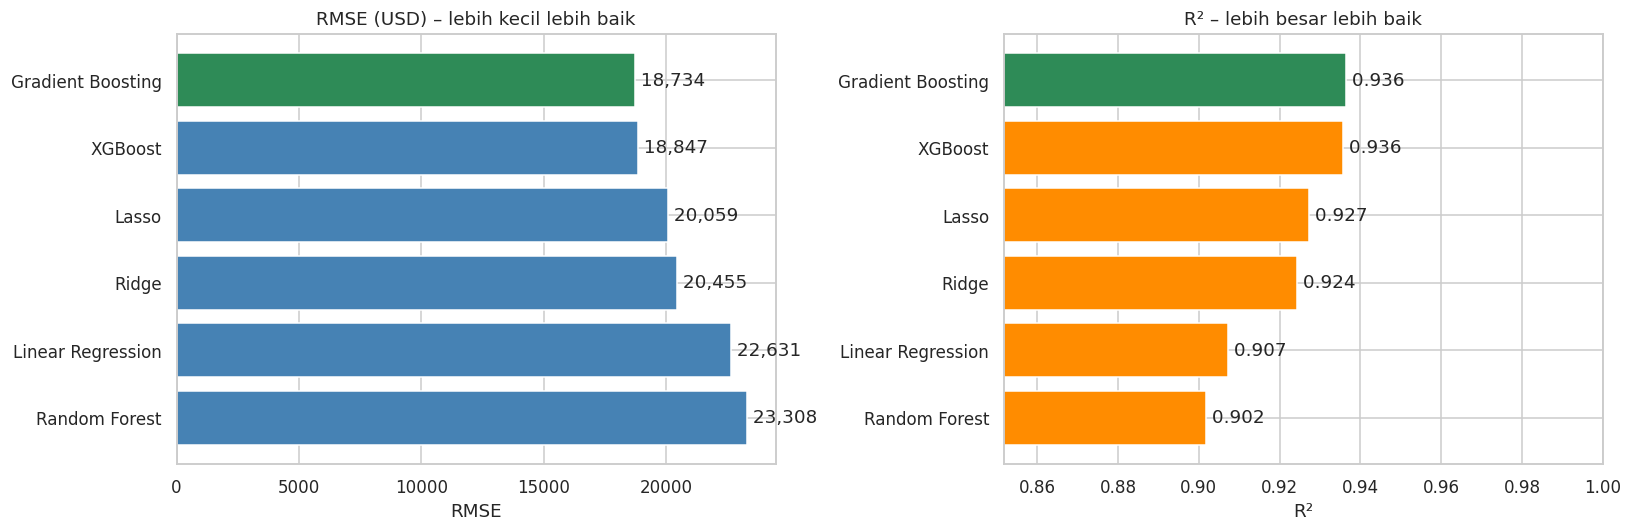

=== Interpretasi otomatis ===
- RMSE terendah: Gradient Boosting (18,734); tertinggi: Random Forest (23,308).
- Rata-rata RMSE model linear = 21,048 vs model pohon/ensemble = 20,297.
- Urutan berdasarkan CV RMSLE (5-fold, data latih): Lasso < Ridge < XGBoost < Gradient Boosting < Linear Regression < Random Forest.
- Model terbaik hold-out (Gradient Boosting) bukan yang terbaik (peringkat 4) pada CV.


In [36]:
order = results_df.sort_values('RMSE')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
cols = ['#2e8b57' if i == 0 else 'steelblue' for i in range(len(order))]
ax[0].barh(order['Model'], order['RMSE'], color=cols); ax[0].invert_yaxis()
ax[0].set_title('RMSE (USD) – lebih kecil lebih baik'); ax[0].set_xlabel('RMSE')
for i, v in enumerate(order['RMSE']): ax[0].text(v, i, f' {v:,.0f}', va='center')
o2 = results_df.sort_values('R2', ascending=False)
cols2 = ['#2e8b57' if i == 0 else 'darkorange' for i in range(len(o2))]
ax[1].barh(o2['Model'], o2['R2'], color=cols2); ax[1].invert_yaxis()
ax[1].set_title('R² – lebih besar lebih baik'); ax[1].set_xlabel('R²')
lo = max(0, o2['R2'].min() - 0.05); ax[1].set_xlim(lo, 1)
for i, v in enumerate(o2['R2']): ax[1].text(v, i, f' {v:.3f}', va='center')
plt.tight_layout(); save_fig('08_model_comparison.png'); plt.show()

print("=== Interpretasi otomatis ===")
b, w = results_df.iloc[0], results_df.iloc[-1]
print(f"- RMSE terendah: {b['Model']} ({b['RMSE']:,.0f}); tertinggi: {w['Model']} ({w['RMSE']:,.0f}).")
fam_lin = results_df[results_df['Model'].isin(['Linear Regression', 'Ridge', 'Lasso'])]
fam_tree = results_df[~results_df['Model'].isin(['Linear Regression', 'Ridge', 'Lasso'])]
print(f"- Rata-rata RMSE model linear = {fam_lin['RMSE'].mean():,.0f} vs model pohon/ensemble = {fam_tree['RMSE'].mean():,.0f}.")
rank_cv = results_df.sort_values('CV_RMSLE_mean')['Model'].tolist()
print(f"- Urutan berdasarkan CV RMSLE (5-fold, data latih): {' < '.join(rank_cv)}.")
print(f"- Model terbaik hold-out ({b['Model']}) {'juga terbaik' if rank_cv[0] == b['Model'] else 'bukan yang terbaik (peringkat ' + str(rank_cv.index(b['Model'])+1) + ')'} pada CV.")

# 17. Best Model
Model terbaik ditentukan **setelah semua model dijalankan**, berdasarkan RMSE terendah pada hold-out (dengan CV RMSLE sebagai pembanding kestabilan).

In [37]:
best_row = results_df.iloc[0]
best_name = best_row['Model']
best_model = fitted[best_name]
pred_best = preds[best_name]

print(f"MODEL TERBAIK : {best_name}")
print(f"RMSE          : {best_row['RMSE']:,.0f} USD")
print(f"MAE           : {best_row['MAE']:,.0f} USD")
print(f"R²            : {best_row['R2']:.4f}")
print(f"RMSLE         : {best_row['RMSLE']:.4f}   | CV RMSLE: {best_row['CV_RMSLE_mean']:.4f} ± {best_row['CV_RMSLE_std']:.4f}")
print(f"Best params   : {best_row['Best_Params']}")
second = results_df.iloc[1]
print(f"\nAlasan dipilih: RMSE terendah dari {len(results_df)} model; lebih baik {second['RMSE'] - best_row['RMSE']:,.0f} USD "
      f"({(1 - best_row['RMSE']/second['RMSE'])*100:.1f}%) dibanding peringkat 2 ({second['Model']}). "
      f"Rata-rata galat absolut {best_row['MAE']:,.0f} USD ≈ {best_row['MAE']/y_test.mean()*100:.1f}% dari rata-rata harga hold-out; "
      f"model menjelaskan {best_row['R2']*100:.1f}% variasi harga.")

MODEL TERBAIK : Gradient Boosting
RMSE          : 18,734 USD
MAE           : 13,541 USD
R²            : 0.9365
RMSLE         : 0.1157   | CV RMSLE: 0.1169 ± 0.0129
Best params   : {}

Alasan dipilih: RMSE terendah dari 6 model; lebih baik 113 USD (0.6%) dibanding peringkat 2 (XGBoost). Rata-rata galat absolut 13,541 USD ≈ 7.5% dari rata-rata harga hold-out; model menjelaskan 93.6% variasi harga.


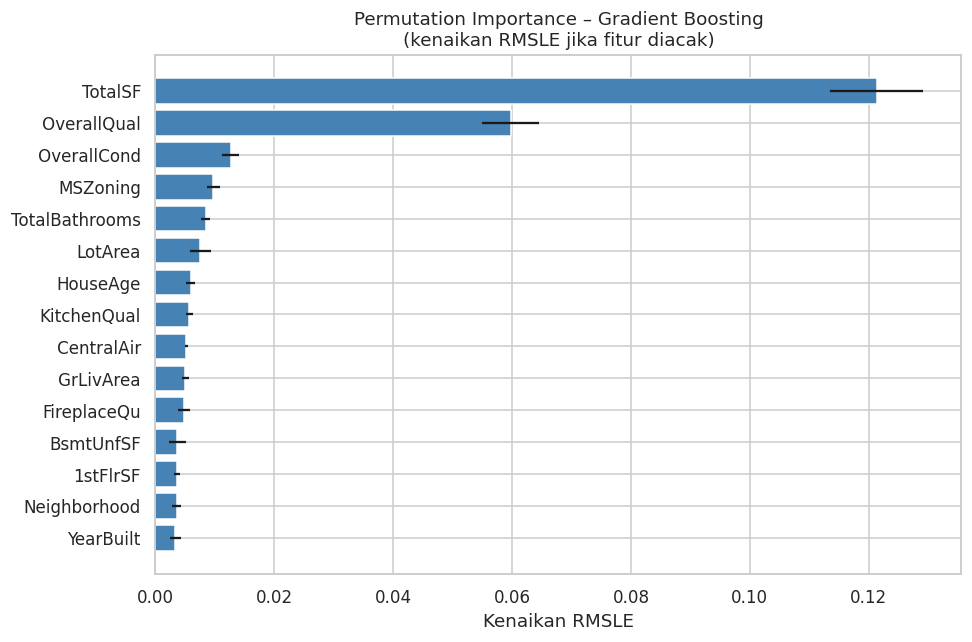

,Feature,Importance,Std
0,TotalSF,0.1213,0.0078
1,OverallQual,0.0598,0.0048
2,OverallCond,0.0127,0.0015
3,MSZoning,0.0098,0.0011
4,TotalBathrooms,0.0085,0.0008
5,LotArea,0.0076,0.0018
6,HouseAge,0.0059,0.0008
7,KitchenQual,0.0057,0.0006
8,CentralAir,0.0052,0.0002
9,GrLivArea,0.0050,0.0006


Interpretasi otomatis: 5 fitur paling berpengaruh pada model terbaik -> TotalSF, OverallQual, OverallCond, MSZoning, TotalBathrooms.
Fitur baru yang masuk 15 teratas: ['TotalSF', 'TotalBathrooms', 'HouseAge']


In [38]:
# Fitur paling berpengaruh: permutation importance pada hold-out (fitur ASLI, sebelum one-hot)
perm = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                              scoring='neg_root_mean_squared_log_error', n_jobs=-1)
imp_df = (pd.DataFrame({'Feature': X_test.columns, 'Importance': perm.importances_mean, 'Std': perm.importances_std})
          .sort_values('Importance', ascending=False).reset_index(drop=True))
top_imp = imp_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top_imp['Feature'][::-1], top_imp['Importance'][::-1], xerr=top_imp['Std'][::-1], color='steelblue')
plt.title(f'Permutation Importance – {best_name}\n(kenaikan RMSLE jika fitur diacak)')
plt.xlabel('Kenaikan RMSLE'); plt.tight_layout(); save_fig('11_permutation_importance.png'); plt.show()
display(top_imp.head(10).round(4))
print("Interpretasi otomatis: 5 fitur paling berpengaruh pada model terbaik -> " + ", ".join(imp_df['Feature'].head(5)) + ".")
print("Fitur baru yang masuk 15 teratas:", [f for f in top_imp['Feature'] if f in NEW_FEATURES] or "tidak ada")

# 18. Prediction Analysis
## 18.1 Actual vs Predicted dan Residual (model terbaik)

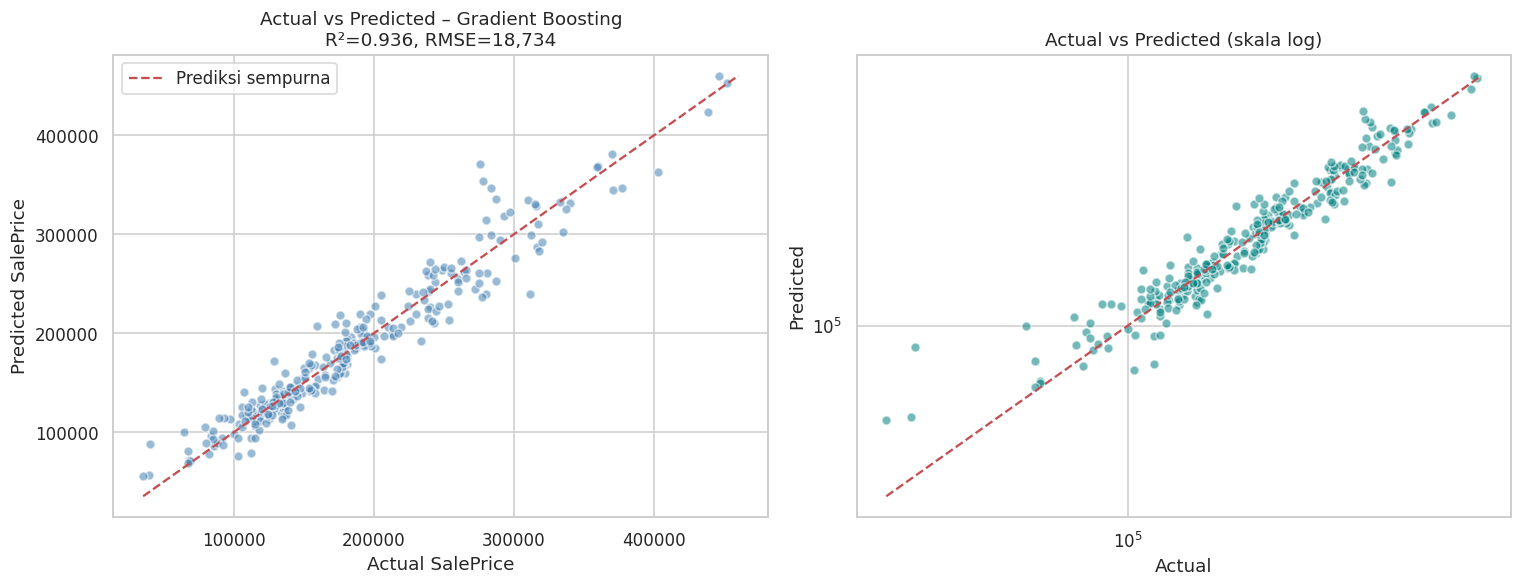

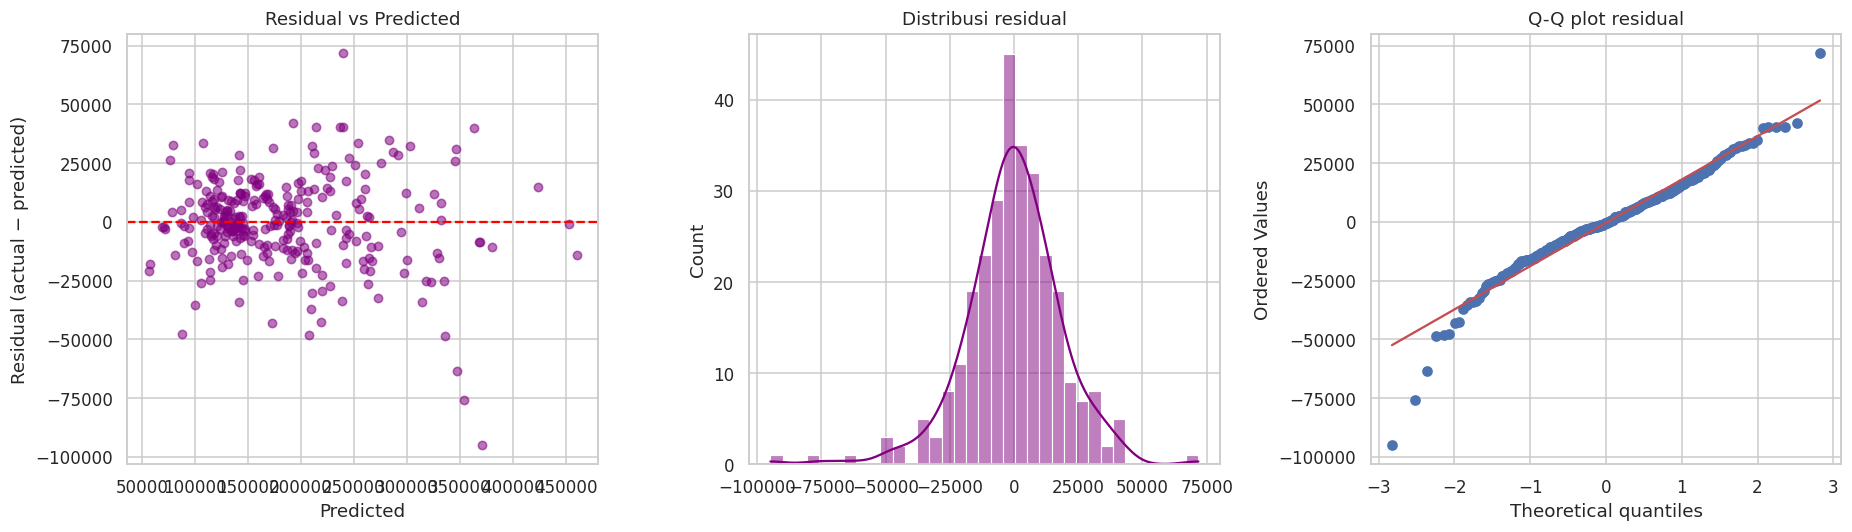

,MAE,MAPE_pct,Mean_Residual
seg,,,
Q1 (termurah),10779.0,12.5,-4342.4
Q2,9413.5,6.5,1293.8
Q3,11969.0,6.4,-860.7
Q4 (termahal),22003.8,7.8,2467.5


=== Interpretasi otomatis ===
- Rata-rata residual = -360 USD (mendekati 0 berarti tidak bias sistematis); std residual = 18,731.
- MAE segmen termurah 10,779 vs termahal 22,004 USD; galat relatif (MAPE) 12.5% vs 7.8%.
- Korelasi prediksi vs |residual| = 0.36 -> galat absolut membesar seiring naiknya harga (heteroskedastisitas ya).
- Pada segmen termahal rata-rata residual = 2,467 USD -> model cenderung meremehkan (under-predict) rumah mahal.


In [39]:
resid = y_test.values - pred_best
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].scatter(y_test, pred_best, alpha=.55, color='steelblue', edgecolor='white', s=35)
lim = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
ax[0].plot(lim, lim, 'r--', label='Prediksi sempurna'); ax[0].legend()
ax[0].set_xlabel('Actual SalePrice'); ax[0].set_ylabel('Predicted SalePrice')
ax[0].set_title(f'Actual vs Predicted – {best_name}\nR²={best_row["R2"]:.3f}, RMSE={best_row["RMSE"]:,.0f}')
ax[1].scatter(y_test, pred_best, alpha=.55, color='teal', edgecolor='white', s=35)
ax[1].plot(lim, lim, 'r--'); ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_title('Actual vs Predicted (skala log)'); ax[1].set_xlabel('Actual'); ax[1].set_ylabel('Predicted')
plt.tight_layout(); save_fig('09_actual_vs_predicted.png'); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].scatter(pred_best, resid, alpha=.55, color='purple', s=30); ax[0].axhline(0, color='red', ls='--')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Residual (actual − predicted)'); ax[0].set_title('Residual vs Predicted')
sns.histplot(resid, kde=True, bins=35, ax=ax[1], color='purple'); ax[1].set_title('Distribusi residual')
stats.probplot(resid, dist='norm', plot=ax[2]); ax[2].set_title('Q-Q plot residual')
plt.tight_layout(); save_fig('10_residuals.png'); plt.show()

# Pola error berdasarkan segmen harga
seg = pd.qcut(y_test, 4, labels=['Q1 (termurah)', 'Q2', 'Q3', 'Q4 (termahal)'])
seg_df = pd.DataFrame({'seg': seg.values, 'abs_err': np.abs(resid), 'pct_err': np.abs(resid) / y_test.values * 100, 'resid': resid})
seg_tab = seg_df.groupby('seg', observed=True).agg(MAE=('abs_err', 'mean'), MAPE_pct=('pct_err', 'mean'), Mean_Residual=('resid', 'mean'))
display(seg_tab.round(1))
corr_abs = np.corrcoef(pred_best, np.abs(resid))[0, 1]
print("=== Interpretasi otomatis ===")
print(f"- Rata-rata residual = {resid.mean():,.0f} USD (mendekati 0 berarti tidak bias sistematis); std residual = {resid.std():,.0f}.")
print(f"- MAE segmen termurah {seg_tab['MAE'].iloc[0]:,.0f} vs termahal {seg_tab['MAE'].iloc[-1]:,.0f} USD; "
      f"galat relatif (MAPE) {seg_tab['MAPE_pct'].iloc[0]:.1f}% vs {seg_tab['MAPE_pct'].iloc[-1]:.1f}%.")
print(f"- Korelasi prediksi vs |residual| = {corr_abs:.2f} -> galat absolut {'membesar seiring naiknya harga' if corr_abs > 0.3 else 'tidak terlalu bergantung pada level harga'} (heteroskedastisitas {'ya' if corr_abs > 0.3 else 'ringan'}).")
bias_top = seg_tab['Mean_Residual'].iloc[-1]
print(f"- Pada segmen termahal rata-rata residual = {bias_top:,.0f} USD -> model cenderung {'meremehkan (under-predict)' if bias_top > 0 else 'melebihkan (over-predict)'} rumah mahal.")

In [40]:
# 10 prediksi dengan galat terbesar
err = X_test[['Neighborhood', 'OverallQual', 'GrLivArea', 'TotalSF', 'HouseAge']].copy()
err['Actual'], err['Predicted'] = y_test.values, pred_best.round(0)
err['Error'] = err['Actual'] - err['Predicted']; err['Abs Error %'] = (err['Error'].abs() / err['Actual'] * 100).round(1)
worst = err.reindex(err['Error'].abs().sort_values(ascending=False).index).head(10)
display(worst)
print(f"10 galat terbesar menyumbang {worst['Error'].abs().sum()/err['Error'].abs().sum()*100:.1f}% dari total galat absolut ({len(err)} rumah hold-out).")

,Neighborhood,OverallQual,GrLivArea,TotalSF,HouseAge,Actual,Predicted,Error,Abs Error %
261,CollgCr,8,2574,4056,0,276000,370833.0,-94833.0,34.4
1043,NWAmes,8,2524,5048,28,278000,353814.0,-75814.0,27.3
218,Crawfor,7,1954,2752,69,311500,239734.0,71766.0,23.0
332,NridgHt,8,1629,4835,6,284000,347240.0,-63240.0,22.3
1023,Timber,8,2898,4463,32,287000,335570.0,-48570.0,16.9
715,OldTown,7,2554,3272,117,159500,207778.0,-48278.0,30.3
30,IDOTRR,4,1317,1966,88,40000,87688.0,-47688.0,119.2
665,NAmes,6,2380,3401,42,129000,172165.0,-43165.0,33.5
1413,Blmngtn,7,1569,2955,2,175900,218619.0,-42719.0,24.3
558,Blmngtn,7,1557,2931,3,234000,191988.0,42012.0,18.0


10 galat terbesar menyumbang 14.6% dari total galat absolut (292 rumah hold-out).


## 18.2 Prediksi `test.csv` (format Kaggle)
Model terbaik dilatih ulang pada seluruh data latih bersih (tanpa 2 outlier), lalu memprediksi 1459 rumah di `test.csv`.

submission.csv: (1459, 2) | format kolom sama dengan sample_submission: True


,count,mean,std,min,25%,50%,75%,max
Prediksi test.csv,1459.0,179015.0,80677.0,39132.0,128170.0,157272.0,207006.0,709110.0


Pembanding SalePrice train: mean=180,933, median=163,000, min=34,900, max=755,000


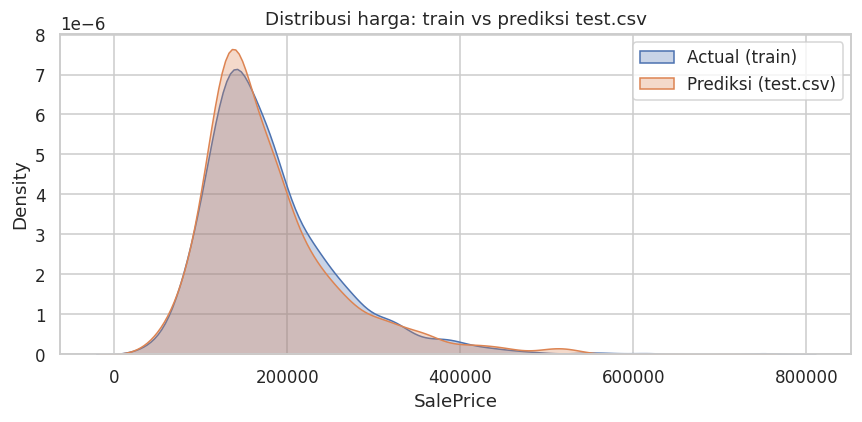

In [41]:
final_model = clone(best_model).fit(X_all, y_all)
test_pred = final_model.predict(X_kaggle_test)
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_pred})
assert list(submission.columns) == list(sample_sub.columns) and len(submission) == len(sample_sub)
assert submission['SalePrice'].notna().all() and (submission['SalePrice'] > 0).all()
submission.to_csv(os.path.join(OUT_DIR, 'submission.csv'), index=False)

print(f"submission.csv: {submission.shape} | format kolom sama dengan sample_submission: True")
display(submission['SalePrice'].describe().to_frame('Prediksi test.csv').T.round(0))
print(f"Pembanding SalePrice train: mean={y_all.mean():,.0f}, median={y_all.median():,.0f}, min={y_all.min():,.0f}, max={y_all.max():,.0f}")
plt.figure(figsize=(8, 4))
sns.kdeplot(y_all, label='Actual (train)', fill=True, alpha=.3); sns.kdeplot(submission['SalePrice'], label='Prediksi (test.csv)', fill=True, alpha=.3)
plt.legend(); plt.title('Distribusi harga: train vs prediksi test.csv'); plt.tight_layout(); plt.show()

# 19. Conclusion
Seluruh jawaban di bawah dihasilkan otomatis dari variabel hasil eksekusi.

In [42]:
def top_list(s, n): return ", ".join(f"{k} ({v:.2f})" for k, v in s.head(n).items())
n_struct = len(ABSENT_RULES) + len(ALWAYS_NONE)
print("="*100)
print("JAWABAN ANALISIS HASIL")
print("="*100)
print(f"""
1. Fitur paling berpengaruh terhadap SalePrice
   - Korelasi Pearson (numerik): {top_list(top_corr, 5)}.
   - Kategorikal (eta²): {', '.join(f'{k} ({v:.2f})' for k, v in eta.head(3).items())}.
   - Permutation importance pada {best_name}: {', '.join(imp_df['Feature'].head(5))}.

2. Penanganan missing value
   - {len(miss_train)} fitur train bermissing; {n_struct} kolom kategori diisi 'None' bila fasilitas tidak ada (diverifikasi dengan kolom ukuran terkait),
     kolom numerik terkait (MasVnrArea, Bsmt*) diisi 0, GarageYrBlt dibuang.
   - Missing sungguhan ({int(X_all.isna().sum().sum())} sel di data latih, mis. LotFrontage) diimputasi di dalam Pipeline: median (numerik) & modus (kategorikal).

3. Penanganan outlier
   - Hanya {len(removed_ids)} baris dihapus (Id {removed_ids}: GrLivArea > 4000 & harga < 300.000). Korelasi GrLivArea-SalePrice {r_before:.3f} -> {r_after:.3f}.
   - Outlier IQR lainnya dipertahankan; efeknya diredam log-transform target, regularisasi, dan model pohon.

4. Pemrosesan variabel kategorikal
   - {len(QUAL_COLS) + len(ORDINAL_MAPS)} kolom berurutan (kualitas, exposure, finish, dsb.) di-encode ORDINAL; sisanya ({len(cat_features)} kolom) One-Hot Encoding
     dengan handle_unknown='ignore'. MSSubClass & MoSold diperlakukan sebagai kategori. Hasil akhir: {Xt_train.shape[1]} kolom setelah preprocessing.

5. Feature engineering
   - {len(NEW_FEATURES)} fitur baru: {', '.join(NEW_FEATURES)}.
   - Ablation RMSLE (tanpa -> dengan fitur baru): Ridge {ablation.loc['Ridge TANPA fitur baru','RMSLE']:.4f} -> {ablation.loc['Ridge DENGAN fitur baru','RMSLE']:.4f}; Gradient Boosting {ablation.loc['Gradient Boosting TANPA fitur baru','RMSLE']:.4f} -> {ablation.loc['Gradient Boosting DENGAN fitur baru','RMSLE']:.4f}.
   - Fitur baru di 15 teratas permutation importance: {[f for f in top_imp['Feature'] if f in NEW_FEATURES] or 'tidak ada'}.

6. Apakah scaling diperlukan?
   - Ridge RMSLE: {ablation.loc['Ridge, scaling=True','RMSLE']:.4f} (scaling) vs {ablation.loc['Ridge, scaling=False','RMSLE']:.4f} (tanpa scaling).
     Selisih {ablation.loc['Ridge, scaling=True','RMSLE'] - ablation.loc['Ridge, scaling=False','RMSLE']:+.5f}: {'scaling terbukti membantu' if ablation.loc['Ridge, scaling=True','RMSLE'] - ablation.loc['Ridge, scaling=False','RMSLE'] < -0.002 else 'pada data ini scaling tidak memberi perbedaan berarti'}.
     Scaling tetap dipertahankan untuk model linear berregularisasi (penalti alpha berlaku sama untuk semua fitur); model pohon tidak memerlukannya.

7. Model terbaik: {best_name}  (RMSE {best_row['RMSE']:,.0f} | MAE {best_row['MAE']:,.0f} | R² {best_row['R2']:.4f} | RMSLE {best_row['RMSLE']:.4f})
   Urutan RMSE: {' < '.join(f"{r.Model} ({r.RMSE:,.0f})" for r in results_df.itertuples())}

8. Mengapa model tersebut terbaik
   - RMSE terendah dari {len(results_df)} model, {(1 - best_row['RMSE']/second['RMSE'])*100:.1f}% lebih baik dari peringkat 2 ({second['Model']}).
   - Rata-rata RMSE model linear {fam_lin['RMSE'].mean():,.0f} vs model pohon/ensemble {fam_tree['RMSE'].mean():,.0f}.
   - Pada CV 5-fold {best_name} memiliki RMSLE {best_row['CV_RMSLE_mean']:.4f} ({'peringkat 1' if rank_cv[0]==best_name else 'peringkat ' + str(rank_cv.index(best_name)+1)}; terbaik CV: {rank_cv[0]} {results_df.set_index('Model').loc[rank_cv[0],'CV_RMSLE_mean']:.4f}).
   - Catatan jujur: selisih {best_name} vs peringkat 2 hanya {(1 - best_row['RMSE']/second['RMSE'])*100:.1f}% (std CV RMSLE ~{best_row['CV_RMSLE_std']:.3f}); {'ranking konsisten dengan CV.' if rank_cv[0]==best_name else 'peringkat bergeser pada CV sehingga keunggulan model pada satu split hold-out belum tentu pasti.'}

9. Kelemahan model (berdasarkan hasil)
   - Galat relatif segmen termurah {seg_tab['MAPE_pct'].iloc[0]:.1f}% vs termahal {seg_tab['MAPE_pct'].iloc[-1]:.1f}%; galat absolut terbesar di segmen mahal (MAE {seg_tab['MAE'].iloc[-1]:,.0f} USD).
   - Residual {'cenderung' if corr_abs > 0.3 else 'tidak terlalu'} heteroskedastik (korelasi prediksi vs |residual| = {corr_abs:.2f}).
   - Evaluasi bertumpu pada satu split hold-out ({len(y_test)} rumah); 10 galat terbesar menyumbang {worst['Error'].abs().sum()/err['Error'].abs().sum()*100:.1f}% total galat.
   - Hanya data Ames, Iowa (2006–2010): belum tentu berlaku untuk kota/periode lain.

10. Pengembangan yang dapat dilakukan
   - Koreksi skewness fitur numerik (log/Box-Cox) untuk model linear; target encoding Neighborhood.
   - Tuning lebih luas (RandomizedSearchCV/Optuna) untuk Random Forest, Gradient Boosting, XGBoost.
   - Stacking/blending model linear + boosting; evaluasi dengan repeated K-Fold.
   - Fitur interaksi (mis. OverallQual × TotalSF), fitur lokasi/ekonomi tambahan, dan penanganan khusus segmen rumah mahal.
""")

JAWABAN ANALISIS HASIL

1. Fitur paling berpengaruh terhadap SalePrice
   - Korelasi Pearson (numerik): OverallQual (0.80), GrLivArea (0.73), TotalBsmtSF (0.65), GarageCars (0.64), 1stFlrSF (0.63).
   - Kategorikal (eta²): Neighborhood (0.55), ExterQual (0.49), BsmtQual (0.47).
   - Permutation importance pada Gradient Boosting: TotalSF, OverallQual, OverallCond, MSZoning, TotalBathrooms.

2. Penanganan missing value
   - 19 fitur train bermissing; 15 kolom kategori diisi 'None' bila fasilitas tidak ada (diverifikasi dengan kolom ukuran terkait),
     kolom numerik terkait (MasVnrArea, Bsmt*) diisi 0, GarageYrBlt dibuang.
   - Missing sungguhan (262 sel di data latih, mis. LotFrontage) diimputasi di dalam Pipeline: median (numerik) & modus (kategorikal).

3. Penanganan outlier
   - Hanya 2 baris dihapus (Id [524, 1299]: GrLivArea > 4000 & harga < 300.000). Korelasi GrLivArea-SalePrice 0.709 -> 0.735.
   - Outlier IQR lainnya dipertahankan; efeknya diredam log-transform target, regulari